# Learning the Lennard-Jones (LJ) Potential
This notebook demonstrates how to learn a **pair potential** (e.g., Lennard-Jones) from Molecular Dynamics (MD) simulations by optimizing against **Radial Distribution Functions (RDFs)** and **Velocity Auto-Correlation Functions (VACFs)**.

### **Key Concepts**
- **Lennard-Jones Potential**: Describes interactions between two particles:

$$
  U(r) = 4 \varepsilon \left[ \left( \frac{\sigma}{r} \right)^{12} - \left( \frac{\sigma}{r} \right)^6 \right] 

  $$
- **MD Simulations**: Use **Nose-Hoover Chain thermostat** to evolve the system.
- **Objective**: Learn a potential function that reproduces the RDF and VACF of a reference system.


## Importing Required Libraries

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

from ase import Atoms
from ase.lattice.cubic import FaceCenteredCubic, Diamond
from ase.visualize import *

from data_src.data import *
from potential_src.pairMLP.potential_PairMLP import *
from observables.rdf import *
from observables.observers import *   
from utils.get_utils import *

In [ ]:
def plot_vacf(vacf_sim, vacf_target, fn, path, dt=0.01, save_data=False):
    t_range = np.linspace(0.0, vacf_sim.shape[0] * dt, vacf_sim.shape[0])

    plt.figure(figsize=(8, 5))
    plt.plot(t_range, vacf_sim, label='Simulation', linewidth=4, alpha=0.6)

    if vacf_target is not None:
        plt.plot(t_range, vacf_target, label='Target', linewidth=2, linestyle='--', color='black')

    plt.xlabel("Time (fs)")
    plt.ylabel("VACF")
    plt.title("Velocity Auto-Correlation Function (VACF)")
    plt.legend()
    plt.grid()
    plt.show()

    if save_data:
        np.savetxt(f"{path}/vacf_{fn}.txt", np.stack((t_range, vacf_sim), axis=1), delimiter=',')
        np.savetxt(f"{path}/vacf_{fn}_target.txt", np.stack((t_range, vacf_target), axis=1), delimiter=',')

    plt.savefig(f"{path}/vacf_{fn}.pdf", bbox_inches='tight')
    plt.close()

def plot_rdf( g_sim, rdf_target, fn, path, start, nbins, save_data=False, end=2.5):

    bins = np.linspace(start, end, nbins)

    plt.plot(bins, g_sim , label='simulation', linewidth=4, alpha=0.6)
    plt.plot(bins, rdf_target , label='target', linewidth=2,linestyle='--', c='black')
    
    plt.xlabel("$\AA$")
    plt.ylabel("g(r)")

    if save_data:
        np.savetxt(path + '/rdf_{}.txt'.format(fn), np.stack((bins, g_sim)), delimiter=',' )
        np.savetxt(path + '/rdf_{}_target.txt'.format(fn), np.stack((bins, rdf_target)), delimiter=',' )

    plt.show()
    plt.savefig(path + '/rdf_{}.pdf'.format(fn), bbox_inches='tight')
    plt.close()

def plot_pair(fn, path, prior, device, end=2.5, target_pot=None, model=None): 
    if target_pot is None:
        target_pot = LennardJones(sigma=1, epsilon=1)
    else:
        target_pot = target_pot.to("cpu")

    x = torch.linspace(0.1, end, 250)[:, None].to(device)
    
    #u_fit = (model(x) + prior(x)).detach().cpu().numpy()
    u_fit = (prior(x)).detach().cpu().numpy()
    u_fit = u_fit - u_fit[-1] 

    u_target = target_pot(x.detach().cpu()).squeeze()

    plt.plot( x.detach().cpu().numpy(), 
              u_fit, 
              label='fit', linewidth=4, alpha=0.6)
    
    plt.plot( x.detach().cpu().numpy(), 
              u_target.detach().cpu().numpy(),
               label='truth', 
               linewidth=2,linestyle='--', c='black')

    plt.ylim(-2, 4.0)
    plt.legend()      
    plt.show()
    plt.savefig(path + '/potential_{}.jpg'.format(fn), bbox_inches='tight')
    plt.close()

    return u_fit


# System Definition
We first define the **simulation parameters**, such as density, temperature, and the cutoff radius.
We also initialize the **MD system** using ASE (Atomic Simulation Environment).

In [3]:
pair_data_dict = {  'lj_0.3_1.2': {
            'rdf_fn': '../data/LJ_data/rdf_rho0.3_T1.2_dt0.01.csv' ,
            'vacf_fn': '../data/LJ_data/vacf_rho0.3_T1.2_dt0.01.csv' ,
            'rho': 0.3,
            'T': 1.2, 
            'start': 0.75, 
            'end': 3.3,
            'element': "H",
            'mass': 1.0,
            "N_unitcell": 4,
            "cell": FaceCenteredCubic,
            "target_pot": LennardJones(sigma=1,epsilon=1)
            },
  }

width_dict = {'tiny': 64,
               'low': 128,
               'mid': 256, 
               'high': 512}

gaussian_dict = {'tiny': 16,
               'low': 32,
               'mid': 64, 
               'high': 128}


The simulation in this code is self-consistent, meaning all computations are handled within the script without relying on external molecular dynamics software like LAMMPS or GROMACS. Everything—potential evaluation, numerical integration, observables extraction, and model training—is done internally using PyTorch, ASE, and custom simulation modules.

The function 'get_system()' initializes a periodic atomic system in 3D using ASE.
We need to define:
- density
- temperature
- lattice type (e.g. FCC)
- PBCs


In [4]:
def get_system(data_str, device, size):
    # here we define an NVT system setup
    rho = pair_data_dict[data_str]['rho']
    T = pair_data_dict[data_str]['T']
    dim = pair_data_dict[data_str].get("dim", 3)

    if dim == 3:
        # initialize states with ASE 
        cell_module = pair_data_dict[data_str]['cell']
        N_unitcell = pair_data_dict[data_str]['N_unitcell']
        def get_unit_len(rho, N_unitcell):
            L = (N_unitcell / rho) ** (1/3)
            return L 
        L = get_unit_len(rho, N_unitcell)
        print("lattice param:", L)
        atoms = cell_module(symbol=pair_data_dict[data_str]['element'],
                                  size=(size, size, size),
                                  latticeconstant= L,
                                  pbc=True)
        system = System(atoms, device=device)
        system.set_temperature(T)

    return system 

The system uses a ground truth potential (target_pot) from pair_data_dict.
This potential can be:
-Lennard-Jones (LJ) for simple atomic interactions.
-Custom pair potentials for more complex interactions.
This potential is implemented in PyTorch, meaning forces and energies are computed dynamically without external MD engines.


The function get_target_obs() sets up and runs the simulation.


In [5]:
def get_target_obs(system, data_str, n_sim, rdf_range, nbins, t_range, dt, skip=25):
    print("simulating {}".format(data_str))
    device = system.device 
    # simulation setup
    target_pot = pair_data_dict[data_str]['target_pot'] # take target potential
    T = pair_data_dict[data_str]['T'] # take target temperature

    pot = PairPotentials(system, target_pot, cutoff=2.5, nbr_list_device=device).to(device)

    diffeq = NoseHooverChain(pot, 
            system,
            Q=50.0, 
            T=T,
            num_chains=5, 
            adjoint=True,
            topology_update_freq=1).to(system.device)

    # define simulator with 
    sim = Simulations(system, diffeq)

    # define objects for the observables
    rdf_obs = rdf(system, nbins=nbins, r_range=rdf_range)
    vacf_obs = vacf(system, t_range=t_range) 
    
    all_vacf_sim = []

    # Run MD Simulations & Extract Target Data
    for i in range(n_sim):
        v_t, q_t, pv_t = sim.simulate(100, dt=dt, frequency=100) # 100 time steps, dt is given with argparse are in fs, freq is how often the system's state is updated and logged during a md simulation.

        if i >= skip:
            vacf_sim = vacf_obs(v_t).detach().cpu().numpy()
            all_vacf_sim.append(vacf_sim)
            
    # loop over to compute observables 
    trajs = torch.Tensor( np.stack( sim.log['positions'])).to(system.device).detach()
    all_g_sim = []
    for i in range(len(trajs)):

        if i >= skip:
            _, _, g_sim = rdf_obs(trajs[[i]])
            all_g_sim.append(g_sim.detach().cpu().numpy())

    all_g_sim = np.array(all_g_sim).mean(0)
    all_vacf_sim = np.array(all_vacf_sim).mean(0)
    
    return all_g_sim, all_vacf_sim


In [6]:
def get_observer(system, data_str, nbins, t_range, rdf_start):
    # get dt 
    dt = pair_data_dict[data_str].get('dt', 0.01)

    rdf_end = pair_data_dict[data_str].get("end", None)

    xnew = np.linspace(rdf_start , rdf_end, nbins)
    
    # initialize observable function 
    obs = rdf(system, nbins, (rdf_start , rdf_end) )
    vacf_obs = vacf(system, t_range=t_range) 

    # get experimental rdf 
    dim = pair_data_dict[data_str].get("dim", 3) 

    rdf_data_path = pair_data_dict[data_str].get("fn", None)
    # generate simulated data 
    if not rdf_data_path:
        rdf_data, vacf_target = get_target_obs(system, data_str, 200, (rdf_start, rdf_end), nbins=nbins, t_range=t_range, skip=50, dt=dt)
        vacf_target = torch.Tensor(vacf_target).to(system.device)
        rdf_data = np.vstack( (np.linspace(rdf_start, rdf_end, nbins), rdf_data))
    else:
        # experimental rdfs
        rdf_data = np.loadtxt(rdf_data_path, delimiter=',')
        vacf_target = None

    _, rdf_target = get_exp_rdf(rdf_data, nbins, (rdf_start, rdf_end), obs.device, dim=dim)

    # get model potential and simulate 

    return xnew, rdf_target, obs, vacf_target, vacf_obs

In [7]:
def get_sim(system, model, data_str, topology_update_freq=1):

    T = pair_data_dict[data_str]['T']

    diffeq = NoseHooverChain(model, 
            system,
            Q=50.0, 
            T=T,
            num_chains=5, 
            adjoint=True,
            topology_update_freq=topology_update_freq).to(system.device)

    # define simulator with 
    sim = Simulations(system, diffeq)

    return sim

## Define Training Hyperparameters

 – Set learning rate, epochs, and training options.

In [8]:
params = {
    'val': []
}
sys_params = {
    'val': params['val'],
}

In [9]:
n_epochs = 1000
n_sim = 200
size = 4
cutoff = 2.5
t_range = 50
device = 'cpu'

nbins = 100
tau = 60 #assignments['opt_freq']

rdf_start = 0.75
skip = 1

nbr_list_device = 'cpu'
topology_update_freq = 1

data_str_list = ['lj_0.3_1.2']

# Get the grounth truth pair potentials
target_pot = LennardJones(sigma=1,epsilon=1)

# merge paramset a
if sys_params['val']:
    val_str_list = sys_params['val']
else:
    val_str_list = []

project_name = 'lj_sim'
suggestion_id = 'run0'
model_path = '{}/{}'.format(project_name, suggestion_id)
if not os.path.exists(model_path):
    os.makedirs(model_path)

print("Training for {} epochs".format(n_epochs))

train_vacf = True

Training for 1000 epochs


## Initialize the MD System 
– Set up atoms, boundary conditions, and simulation parameters

In [10]:
system_list = []
for data_str in data_str_list+val_str_list:
    system = get_system(data_str, device, size) 
    system_list.append(system)

lattice param: 2.371262202993375


/Users/francescapagano/miniconda3/envs/myenv_mlmd/lib/python3.9/site-packages/ase/md/md.py:52: FutureWarning: Specify the temperature in K using the 'temperature_K' argument
  warnings.warn(FutureWarning(w))


### what is system ? 
System is the starting point for the simulation:

In [11]:
from ase.visualize import view
view(system_list[0])

<Popen: returncode: None args: ['/Users/francescapagano/miniconda3/envs/myen...>

## Potential
- LJ potential is the physics-informed prior potential 
- The neural network model (pairMLP) learns corrections to the prior potential

In [12]:
import torch
import torch.nn as nn

class LJFamily(nn.Module):
    def __init__(self, sigma=1.0, epsilon=1.0, attr_pow=6, rep_pow=12):
        super(LJFamily, self).__init__()
        self.sigma = nn.Parameter(torch.tensor([sigma], dtype=torch.float32, requires_grad=True))
        self.epsilon = nn.Parameter(torch.tensor([epsilon], dtype=torch.float32, requires_grad=True))
        self.attr_pow = attr_pow
        self.rep_pow = rep_pow

    def LJ(self, r):
        return 4 * self.epsilon * ((self.sigma / r)**self.rep_pow - (self.sigma / r)**self.attr_pow)

    def forward(self, x):
        return self.LJ(x)

mlp_parmas = {'n_gauss': int(cutoff//0.10), # cutoff//gaussian_width 
            'r_start': 0.0,
            'r_end': cutoff, 
            'n_width': 128,
            'n_layers': 3,
            'nonlinear': 'ELU'}
lj_params = {'epsilon': 1, 
        'sigma': 1,
    "power": 10}

NN = pairMLP(**mlp_parmas)
pair = LJFamily(epsilon=0.7, sigma=0.7, rep_pow=12, attr_pow=6)  # ExcludedVolume(**lj_params)

model_list = []
for i, data_str in enumerate(data_str_list + val_str_list):
    #pairNN = PairPotentials(system_list[i], NN,
    #            cutoff=cutoff,
    #            nbr_list_device=nbr_list_device
    #            ).to(device)
    prior = PairPotentials(system_list[i], pair,
                    cutoff=2.5,
                nbr_list_device=nbr_list_device
                    ).to(device)

    model = Stack({'pair': prior})
    model_list.append(model)

/Users/francescapagano/Documents/GitHub/mdgrad_mini_clean/srcLJ/potential_src/pairMLP/interface.py:69: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:281.)
  self.cell = torch.Tensor(system.get_cell()).to(system.device)


Stack combines:
- A learned NN potential (pairnn)
- A predefined Lennard-Jones potential (pair)
The model will sum the outputs of pairnn and pair to compute the total energy.


### Data Flow 

Atomic Positions → Compute Pairwise Distances (r_ij) →  
│  
├──> Lennard-Jones Potential (pair) → U_LJ(r_ij)  
│  
├──> Neural Network Potential (pairnn)  
│       ├── GaussianSmearing(r_ij)  
│       ├── Feedforward NN (Linear + ELU Layers)  
│       └── Output: U_MLP(r_ij)  
│  
└──> Final Potential: U_total = U_LJ + U_MLP → Sum Over Pairs → Compute System Energy  
      │  
      └──> Use for Molecular Dynamics (Forces, Simulations, Training)  


In [13]:
model_list

[Stack(
   (models): ModuleDict(
     (pair): PairPotentials(
       (model): LJFamily()
     )
   )
 )]

In [14]:
def count_parameters(model):
    total_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        param_count = param.numel()
        total_params += param_count
        if param.requires_grad:
            trainable_params += param_count
        print(f"{name}: {list(param.shape)} ({param_count} parameters)")
    print(f"\nTotal parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")

count_parameters(model)

models.pair.model.sigma: [1] (1 parameters)
models.pair.model.epsilon: [1] (1 parameters)

Total parameters: 2
Trainable parameters: 2


In [15]:
sim_list = [get_sim(system_list[i], 
                    model_list[i], 
                    data_str,
                    topology_update_freq=topology_update_freq) for i, data_str in enumerate(data_str_list + val_str_list)]
sim_list

This cell initializes and collects observables for each molecular system in data_str_list + val_str_list.
The goal is to compute and store Radial Distribution Function (RDF) and Velocity Auto-Correlation Function (VACF), both for sim and target.

In [16]:
rdf_obs_list = [] #Stores functions to compute RDF during training.
vacf_obs_list = [] #Stores functions to compute VACF during training

rdf_target_list = [] #Stores ground truth RDF data for comparison.
vacf_target_list = [] #Stores ground truth VACF data for comparison.
rdf_bins_list = [] #Stores distance bins for RDF computation

for i, data_str in enumerate(data_str_list + val_str_list):
    rdf_start = pair_data_dict[data_str].get("start", 0.75)
    x, rdf_target, rdf_obs, vacf_target, vacf_obs = get_observer(system_list[i],
                                                                    data_str, 
                                                                    nbins, 
                                                                    t_range=t_range,
                                                                    rdf_start=rdf_start)
    rdf_bins_list.append(x)

    rdf_obs_list.append(rdf_obs)
    rdf_target_list.append(rdf_target)
    vacf_obs_list.append(vacf_obs)
    vacf_target_list.append(vacf_target)


simulating lj_0.3_1.2


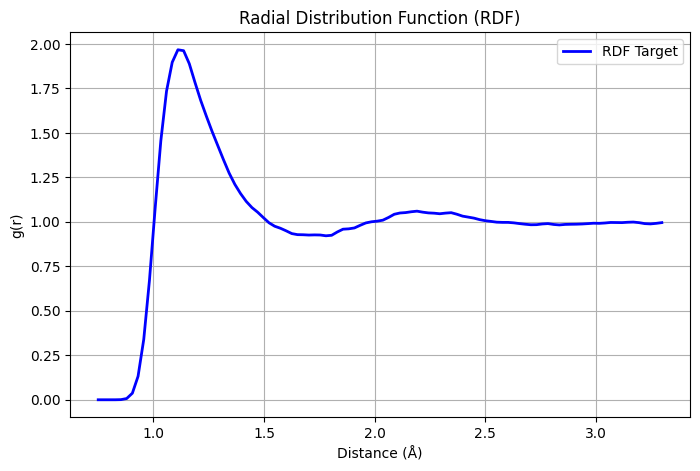

In [17]:
import torch
import matplotlib.pyplot as plt

# Convert tensor to NumPy array
rdf_target = rdf_target_list[0].cpu().numpy()  # Assuming first entry is needed
plt.figure(figsize=(8, 5))
plt.plot(rdf_bins_list[0], rdf_target, label="RDF Target", color='b', linewidth=2)

plt.xlabel("Distance (Å)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function (RDF)")
plt.legend()
plt.grid()
plt.show()


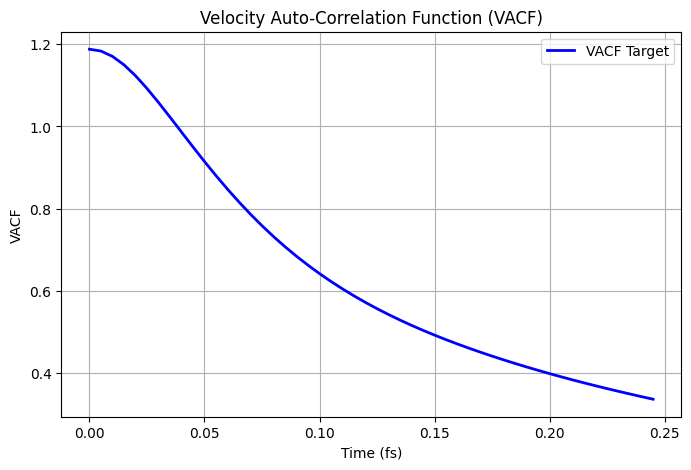

In [18]:
import torch
import matplotlib.pyplot as plt
time_bins = torch.arange(len(vacf_target)).cpu().numpy() * 0.005  # Assuming dt is known

# Convert tensor to NumPy array
vacf_target = vacf_target_list[0].cpu().numpy()  # Assuming first entry is needed
plt.figure(figsize=(8, 5))
plt.plot(time_bins,vacf_target, label="VACF Target", color='b', linewidth=2)


plt.xlabel("Time (fs)")
plt.ylabel("VACF")
plt.title("Velocity Auto-Correlation Function (VACF)")
plt.legend()
plt.grid()
plt.show()


## Initialize Training Components

In [19]:
for name, param in pair.named_parameters():
    print(name, param.shape, param.requires_grad)


sigma torch.Size([1]) True
epsilon torch.Size([1]) True


In [36]:
#optimizer = torch.optim.Adam(list(pair.parameters()), lr=0.01)

optimizer = torch.optim.Adam([
    {'params': pair.sigma, 'lr': 0.01},
    {'params': pair.epsilon, 'lr': 0.05}  # Learning rate più alto per epsilon
])


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                'min', 
                                                min_lr=1e-6, 
                                                verbose=True, factor = 0.5, patience= 20,
                                                threshold=5e-5)

# Set up simulations 
loss_log = []

# 
obs_log = dict()



## Precompute Observables for Training

In [37]:
for i, data_str in enumerate(data_str_list + val_str_list):
    obs_log[data_str] = {}
    obs_log[data_str]['rdf'] = []
    obs_log[data_str]['vacf'] = []

## Training

In [38]:
rdf_weight = 1
vacf_weight = 0.0

q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x320dda6a0>


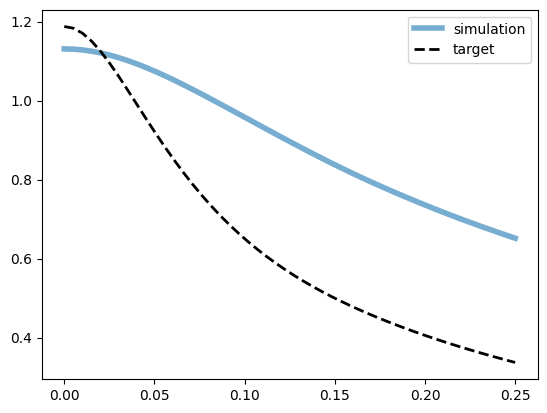

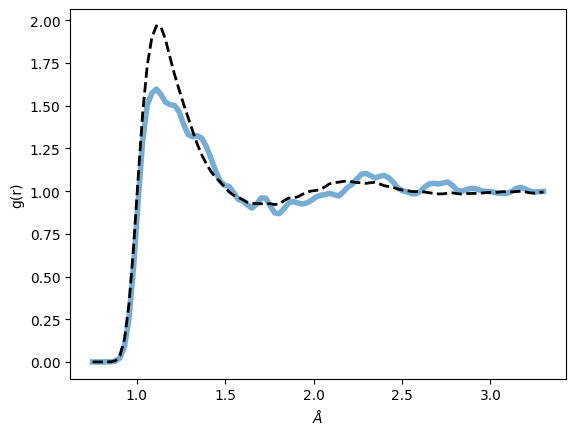

prior:  LJFamily()


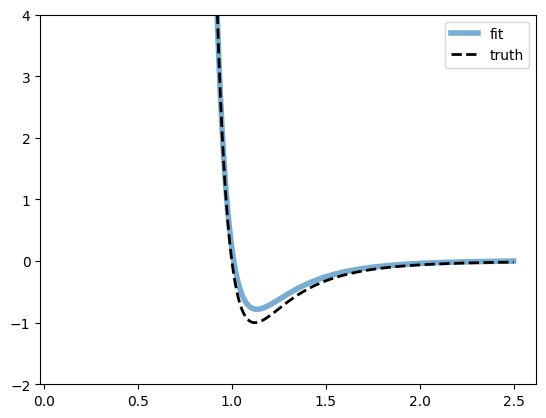

loss.grad_fn: <MulBackward0 object at 0x320d232e0>
Sigma grad: tensor([0.0190])
Epsilon grad: tensor([-0.0099])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.07784779369831085 0.009285975247621536
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3225b1940>
loss.grad_fn: <MulBackward0 object at 0x322aa81f0>
Sigma grad: tensor([-0.1579])
Epsilon grad: tensor([-0.0151])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.08175355941057205 0.0050398074090480804
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322321d90>
loss.grad_fn: <MulBackward0 object at 0x322d17940>
Sigma grad: tensor([-0.0434])
Epsilon grad: tensor([-0.0058])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

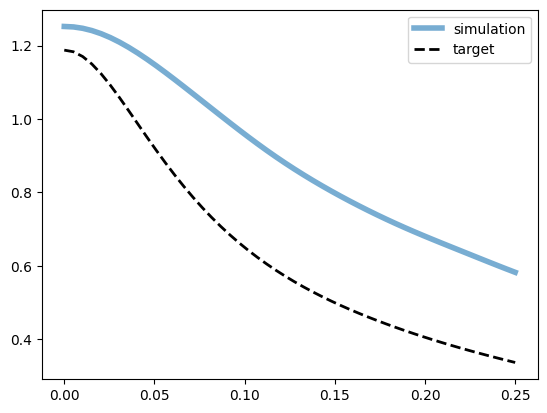

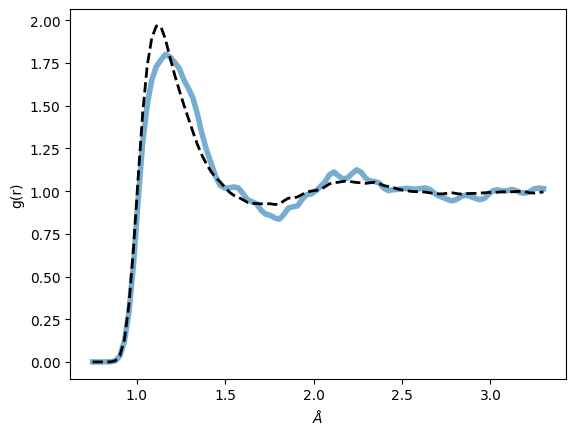

prior:  LJFamily()


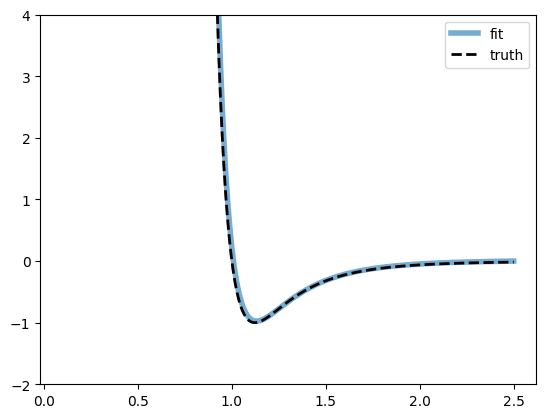

loss.grad_fn: <MulBackward0 object at 0x320dda6a0>
Sigma grad: tensor([0.1479])
Epsilon grad: tensor([-0.0010])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06819380074739456 0.005278710275888443
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32264c640>
loss.grad_fn: <MulBackward0 object at 0x322de25e0>
Sigma grad: tensor([0.0561])
Epsilon grad: tensor([0.0016])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.046505436301231384 0.0009527321672067046
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322de25e0>
loss.grad_fn: <MulBackward0 object at 0x322ac1730>
Sigma grad: tensor([0.1166])
Epsilon grad: tensor([0.0012])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

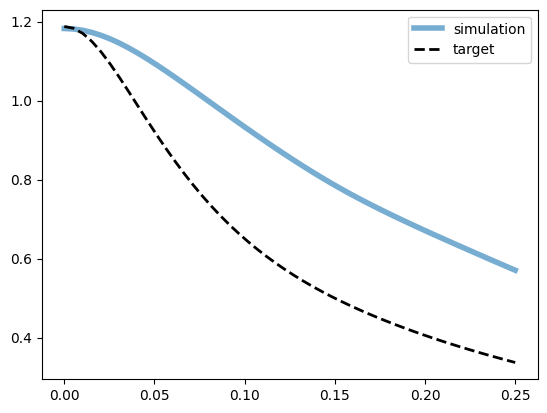

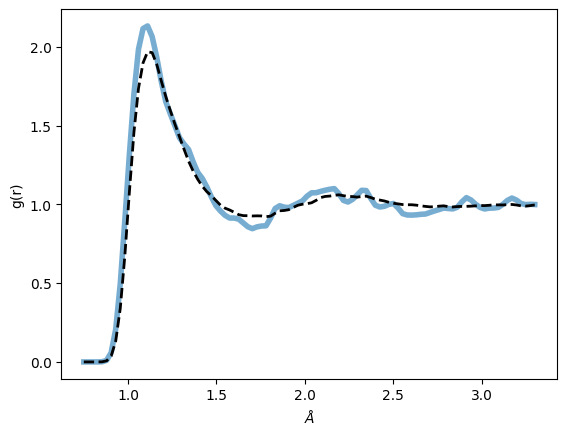

prior:  LJFamily()


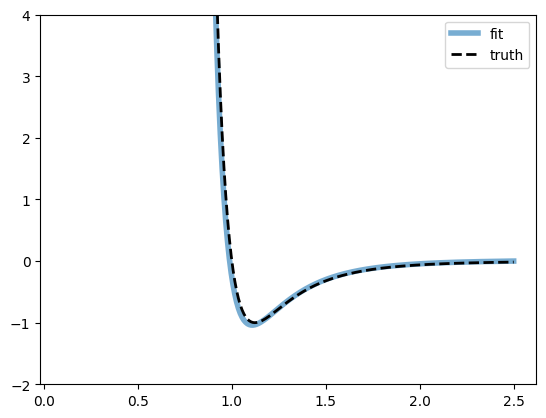

loss.grad_fn: <MulBackward0 object at 0x3225d79a0>
Sigma grad: tensor([-0.2052])
Epsilon grad: tensor([0.0004])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05738649517297745 0.004631455056369305
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3231d6610>
loss.grad_fn: <MulBackward0 object at 0x323403ca0>
Sigma grad: tensor([-0.2998])
Epsilon grad: tensor([-0.0048])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.009849924594163895 0.00489376625046134
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322fe23d0>
loss.grad_fn: <MulBackward0 object at 0x3225d79a0>
Sigma grad: tensor([-0.1858])
Epsilon grad: tensor([-0.0037])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

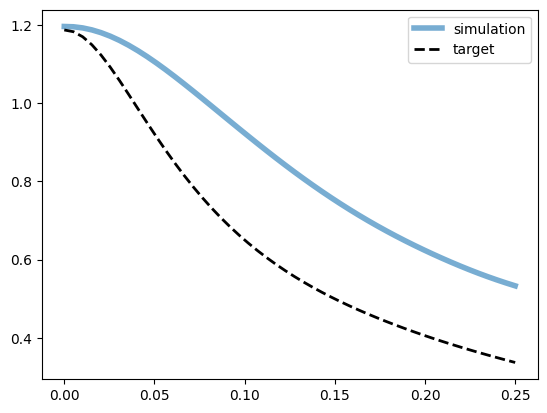

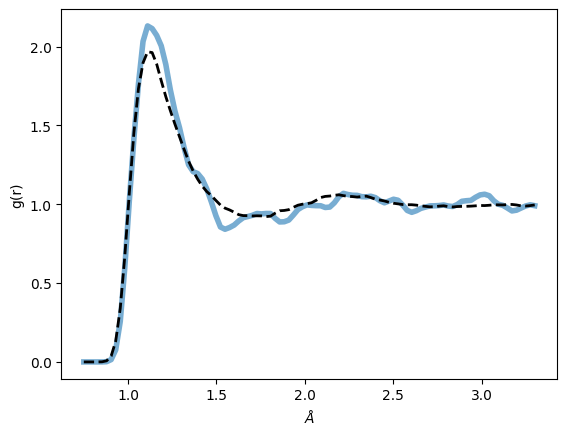

prior:  LJFamily()


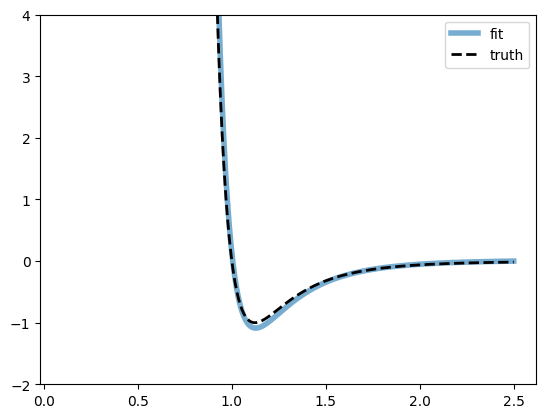

loss.grad_fn: <MulBackward0 object at 0x323403ca0>
Sigma grad: tensor([0.1119])
Epsilon grad: tensor([0.0099])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.047215815633535385 0.0038228416815400124
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a35670>
loss.grad_fn: <MulBackward0 object at 0x3233798e0>
Sigma grad: tensor([0.0302])
Epsilon grad: tensor([0.0060])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.058452166616916656 0.002991241402924061
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32264ca30>
loss.grad_fn: <MulBackward0 object at 0x323560130>
Sigma grad: tensor([0.1649])
Epsilon grad: tensor([0.0063])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

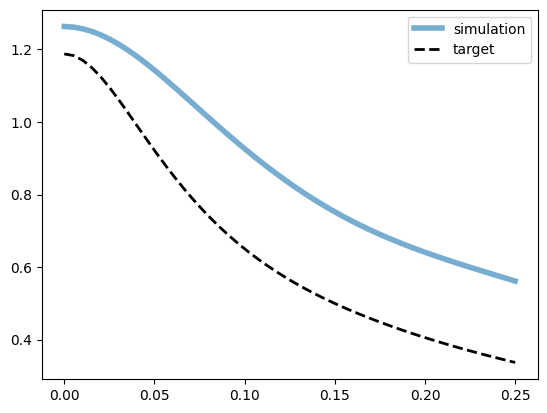

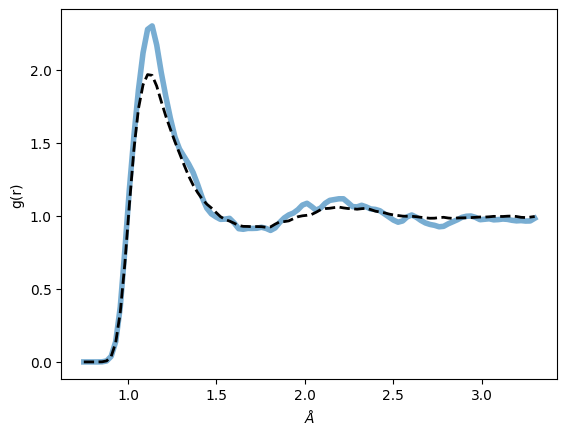

prior:  LJFamily()


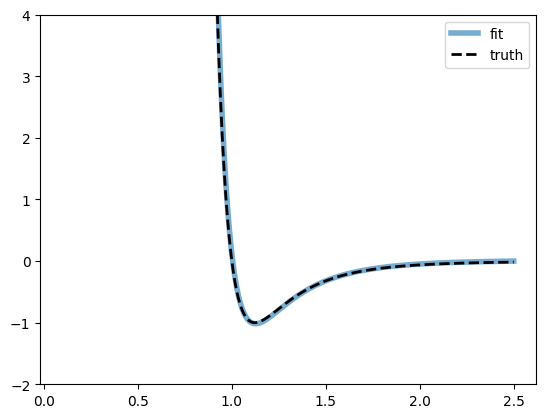

loss.grad_fn: <MulBackward0 object at 0x32265c3d0>
Sigma grad: tensor([0.0660])
Epsilon grad: tensor([0.0106])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05393950641155243 0.005433073733001947
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3224fcb80>
loss.grad_fn: <MulBackward0 object at 0x323560370>
Sigma grad: tensor([0.1445])
Epsilon grad: tensor([0.0141])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.027135496959090233 0.005532045848667622
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323560370>
loss.grad_fn: <MulBackward0 object at 0x322187340>
Sigma grad: tensor([0.0016])
Epsilon grad: tensor([0.0051])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn:

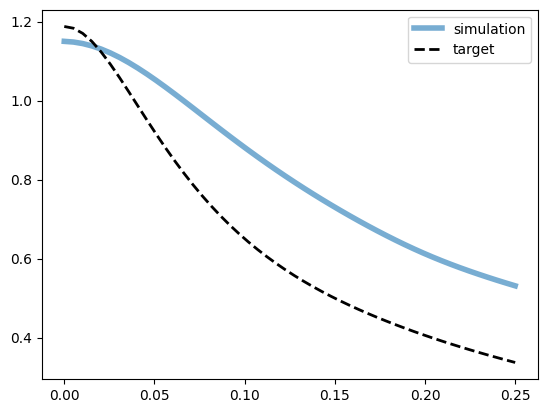

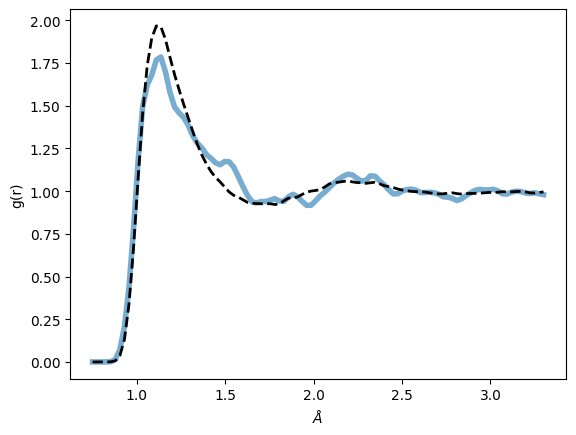

prior:  LJFamily()


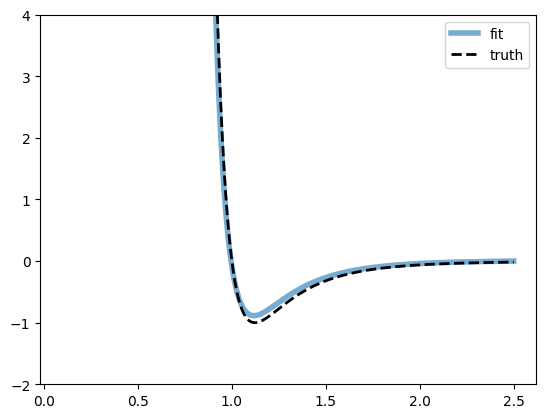

loss.grad_fn: <MulBackward0 object at 0x30b7c55b0>
Sigma grad: tensor([-0.1957])
Epsilon grad: tensor([-0.0156])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03676484152674675 0.004866413306444883
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322395e50>
loss.grad_fn: <MulBackward0 object at 0x30b7c55b0>
Sigma grad: tensor([-0.0616])
Epsilon grad: tensor([-0.0026])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.10338469594717026 0.0017593874363228679
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x30b7c55b0>
loss.grad_fn: <MulBackward0 object at 0x322389a30>
Sigma grad: tensor([-0.1367])
Epsilon grad: tensor([-0.0045])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

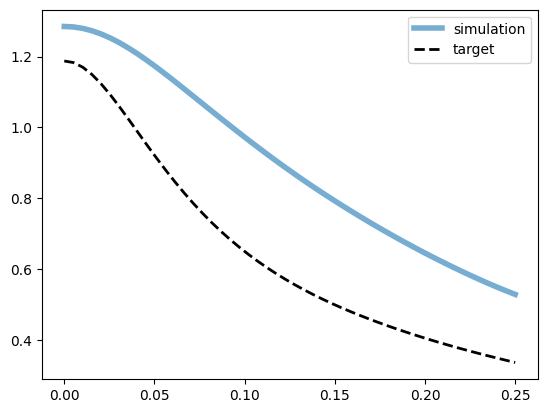

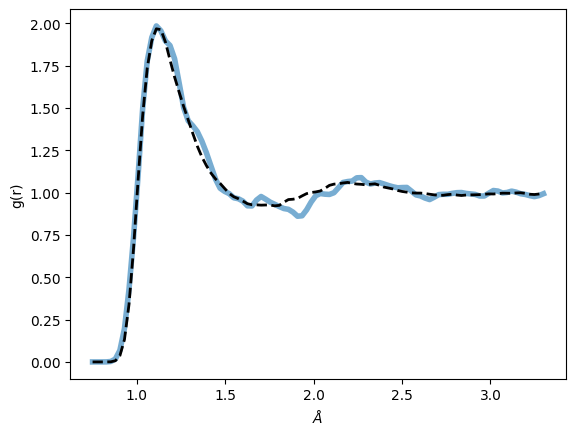

prior:  LJFamily()


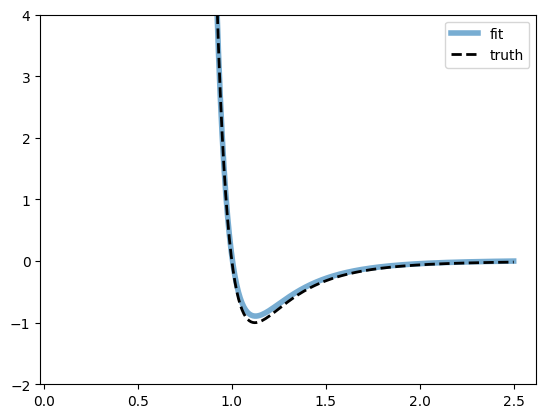

loss.grad_fn: <MulBackward0 object at 0x322395e50>
Sigma grad: tensor([-0.0150])
Epsilon grad: tensor([-0.0003])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06617631763219833 0.0014289898099377751
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322321a00>
loss.grad_fn: <MulBackward0 object at 0x322825190>
Sigma grad: tensor([0.0252])
Epsilon grad: tensor([0.0015])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04611371457576752 0.0018230840796604753
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322f4c100>
loss.grad_fn: <MulBackward0 object at 0x322e411c0>
Sigma grad: tensor([0.1092])
Epsilon grad: tensor([0.0022])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

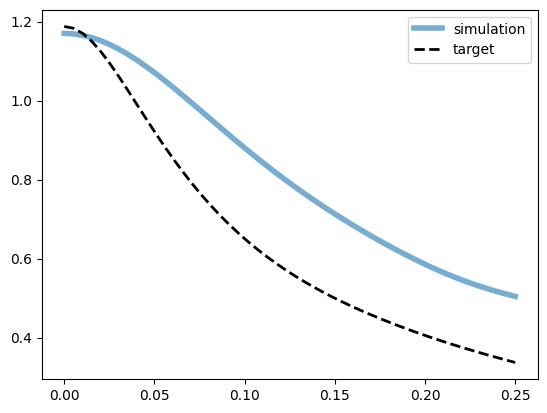

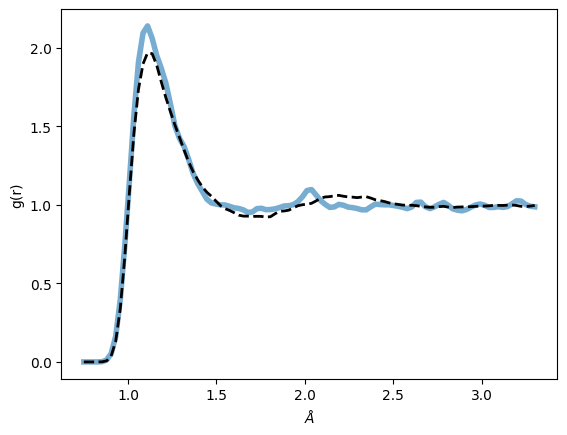

prior:  LJFamily()


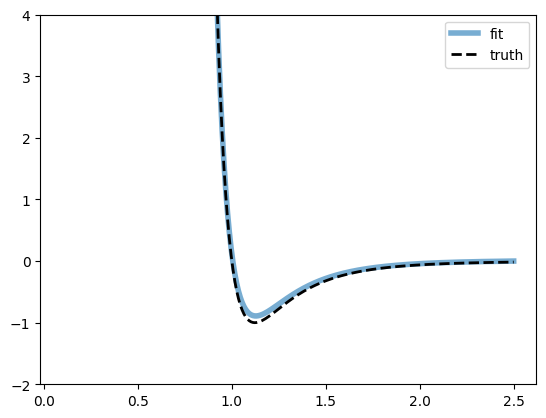

loss.grad_fn: <MulBackward0 object at 0x322395e50>
Sigma grad: tensor([-0.0612])
Epsilon grad: tensor([0.0030])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.032844699919223785 0.002628654008731246
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x305bef640>
loss.grad_fn: <MulBackward0 object at 0x322d846a0>
Sigma grad: tensor([-0.0543])
Epsilon grad: tensor([0.0060])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.040558282285928726 0.00398404523730278
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322d846a0>
loss.grad_fn: <MulBackward0 object at 0x32213dfd0>
Sigma grad: tensor([0.0662])
Epsilon grad: tensor([0.0031])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

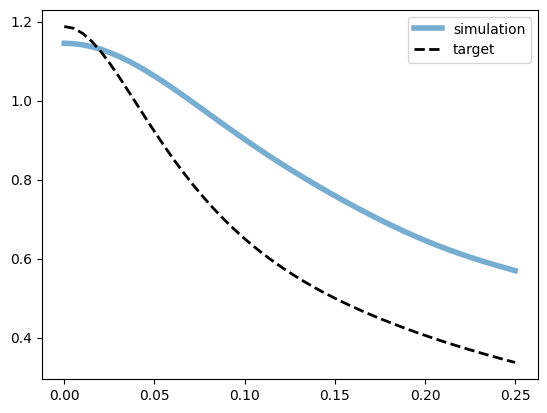

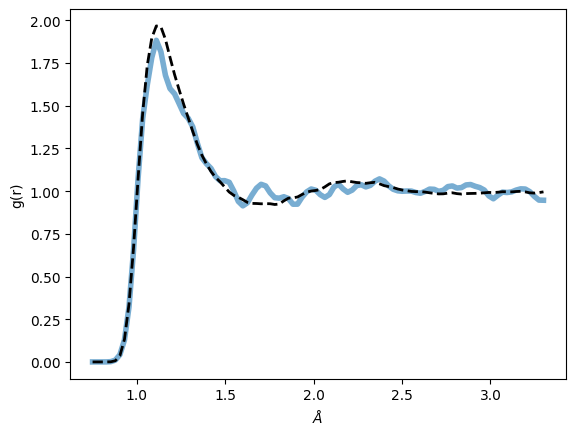

prior:  LJFamily()


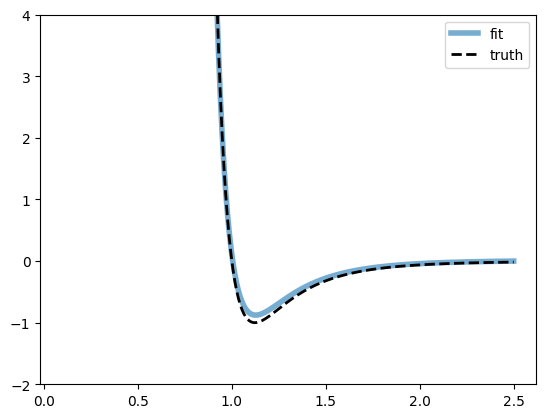

loss.grad_fn: <MulBackward0 object at 0x322144310>
Sigma grad: tensor([-0.0528])
Epsilon grad: tensor([-0.0064])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04663895070552826 0.002547511365264654
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322395e50>
loss.grad_fn: <MulBackward0 object at 0x322d846a0>
Sigma grad: tensor([-0.0557])
Epsilon grad: tensor([-0.0031])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.08553415536880493 0.002964610466733575
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322d846a0>
loss.grad_fn: <MulBackward0 object at 0x3227a6400>
Sigma grad: tensor([-0.0133])
Epsilon grad: tensor([-0.0047])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

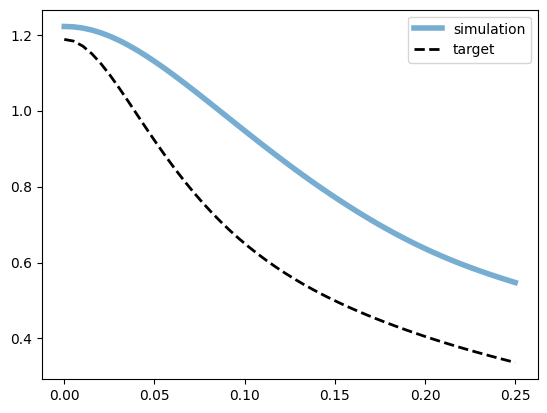

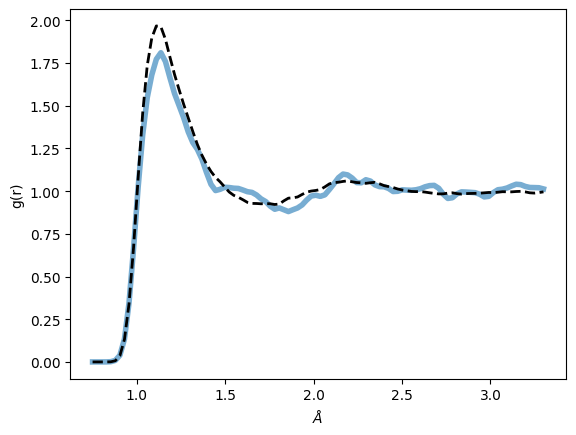

prior:  LJFamily()


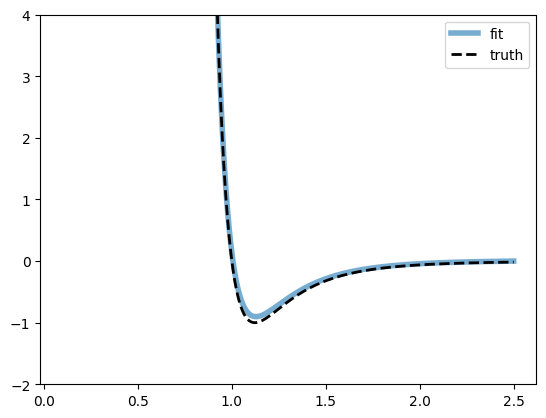

loss.grad_fn: <MulBackward0 object at 0x320b0e910>
Sigma grad: tensor([-0.0357])
Epsilon grad: tensor([-0.0078])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.055649787187576294 0.0032690430525690317
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322144310>
loss.grad_fn: <MulBackward0 object at 0x322d846a0>
Sigma grad: tensor([0.0076])
Epsilon grad: tensor([-0.0031])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06140824407339096 0.0025900995824486017
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x320b0e910>
loss.grad_fn: <MulBackward0 object at 0x3226f88b0>
Sigma grad: tensor([0.0316])
Epsilon grad: tensor([-0.0018])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

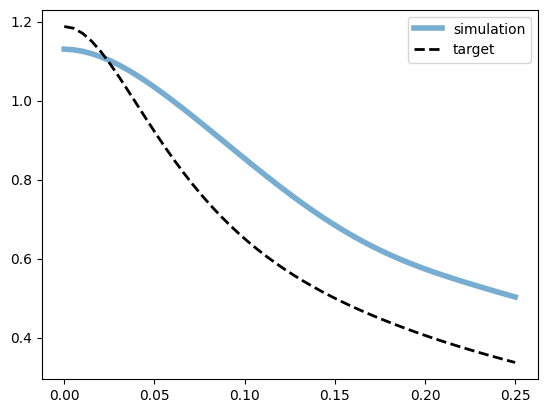

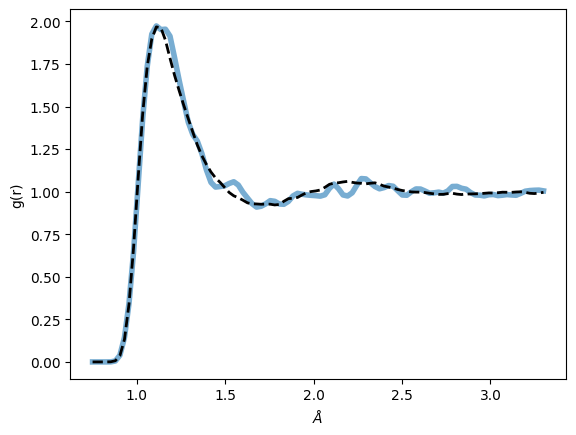

prior:  LJFamily()


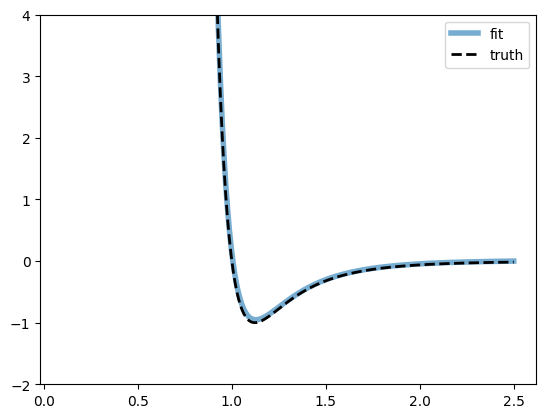

loss.grad_fn: <MulBackward0 object at 0x3226f88b0>
Sigma grad: tensor([0.0625])
Epsilon grad: tensor([0.0030])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.025955405086278915 0.0010861726477742195
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322150af0>
loss.grad_fn: <MulBackward0 object at 0x322863340>
Sigma grad: tensor([0.0762])
Epsilon grad: tensor([0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.029470333829522133 0.0017511936603114009
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322863340>
loss.grad_fn: <MulBackward0 object at 0x322a37880>
Sigma grad: tensor([-0.0883])
Epsilon grad: tensor([-0.0056])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

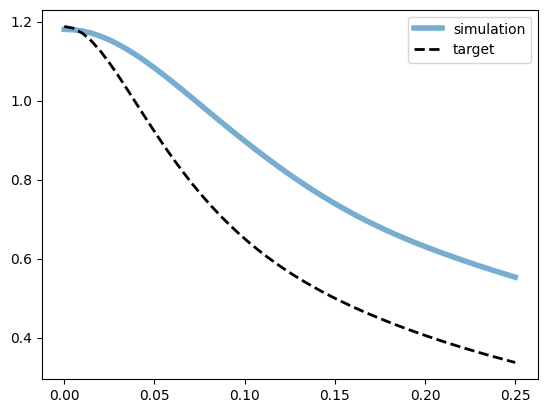

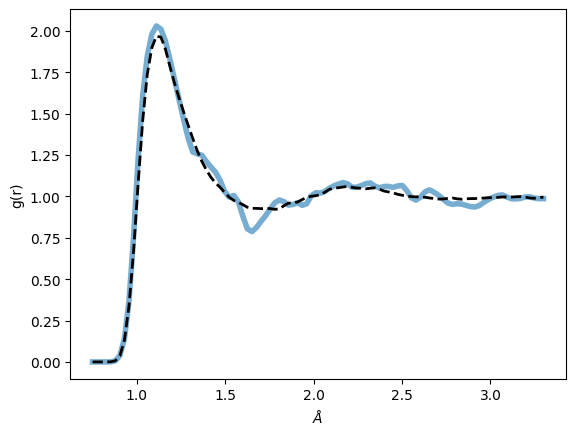

prior:  LJFamily()


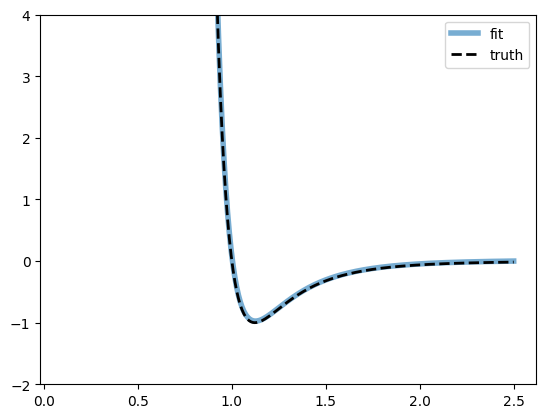

loss.grad_fn: <MulBackward0 object at 0x3229d3cd0>
Sigma grad: tensor([-0.0836])
Epsilon grad: tensor([0.0001])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04319385066628456 0.0021849668119102716
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322d2e400>
loss.grad_fn: <MulBackward0 object at 0x322a37880>
Sigma grad: tensor([-0.0197])
Epsilon grad: tensor([0.0021])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.09276273101568222 0.001851130393333733
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a00130>
loss.grad_fn: <MulBackward0 object at 0x322dba1f0>
Sigma grad: tensor([0.1115])
Epsilon grad: tensor([-0.0018])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

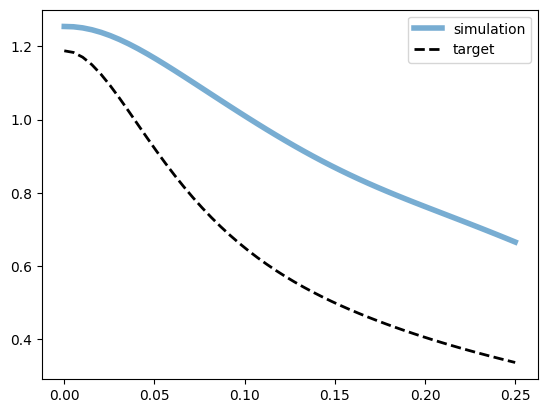

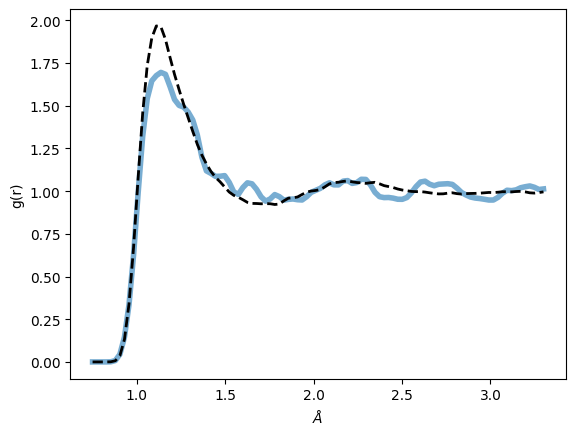

prior:  LJFamily()


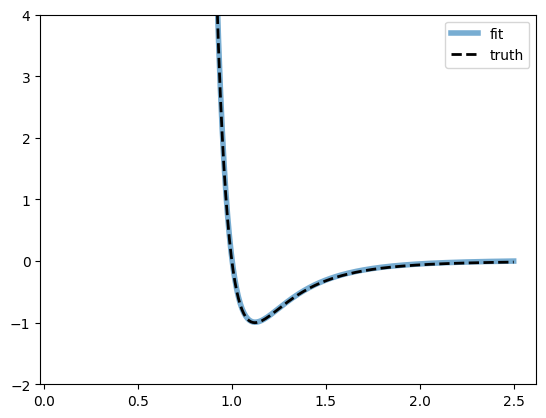

loss.grad_fn: <MulBackward0 object at 0x322a37880>
Sigma grad: tensor([-0.0047])
Epsilon grad: tensor([-0.0079])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.10146123915910721 0.005255946423858404
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a58af0>
loss.grad_fn: <MulBackward0 object at 0x322150af0>
Sigma grad: tensor([0.0087])
Epsilon grad: tensor([-0.0040])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.035629428923130035 0.0019247079035267234
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322150af0>
loss.grad_fn: <MulBackward0 object at 0x3231873d0>
Sigma grad: tensor([-0.1030])
Epsilon grad: tensor([0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

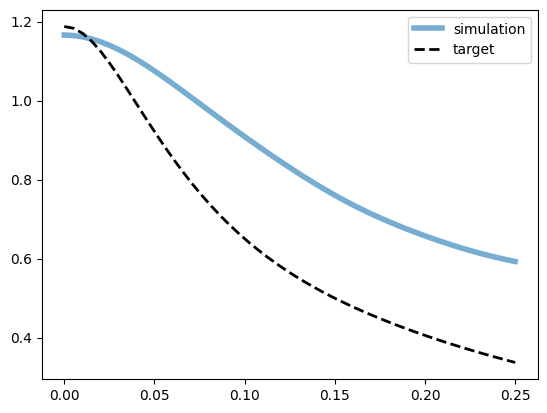

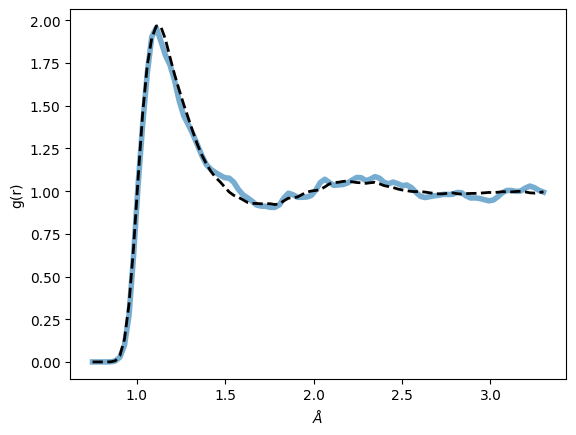

prior:  LJFamily()


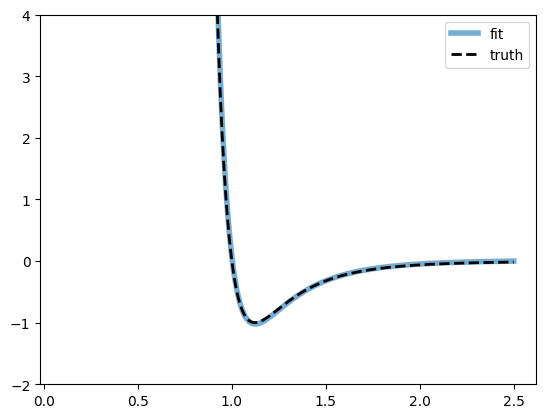

loss.grad_fn: <MulBackward0 object at 0x323187f70>
Sigma grad: tensor([0.0149])
Epsilon grad: tensor([-0.0013])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05029520019888878 0.0010135400807484984
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32341c250>
loss.grad_fn: <MulBackward0 object at 0x323152c40>
Sigma grad: tensor([-0.0235])
Epsilon grad: tensor([0.0005])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.1317288875579834 0.001374074025079608
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323489ac0>
loss.grad_fn: <MulBackward0 object at 0x32348ee80>
Sigma grad: tensor([-0.0152])
Epsilon grad: tensor([0.0025])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

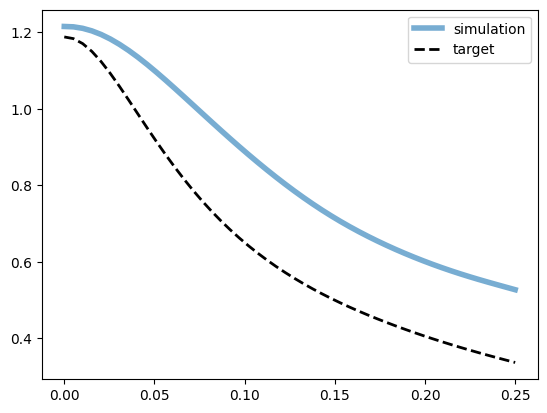

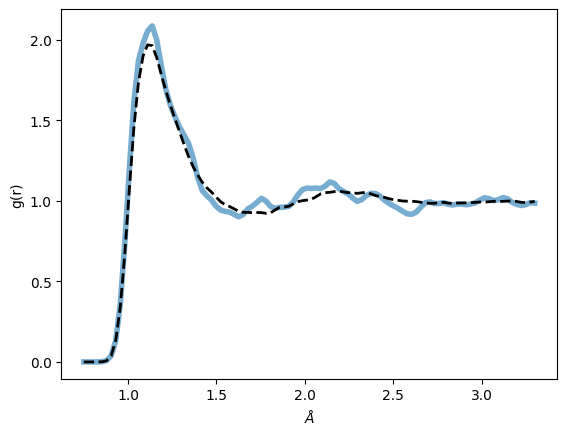

prior:  LJFamily()


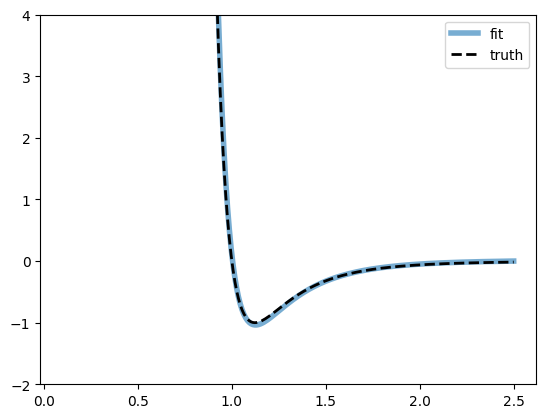

loss.grad_fn: <MulBackward0 object at 0x323489ac0>
Sigma grad: tensor([-0.0782])
Epsilon grad: tensor([0.0012])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03775525465607643 0.002275308594107628
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32341cc10>
loss.grad_fn: <MulBackward0 object at 0x3231873d0>
Sigma grad: tensor([-0.0007])
Epsilon grad: tensor([0.0056])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.020718898624181747 0.0018138325540348887
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3231873d0>
loss.grad_fn: <MulBackward0 object at 0x3233960d0>
Sigma grad: tensor([0.1020])
Epsilon grad: tensor([0.0082])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

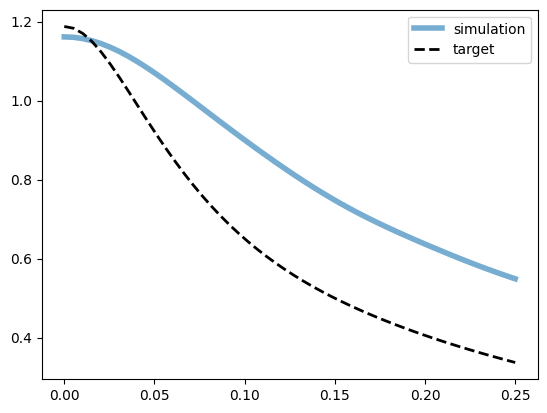

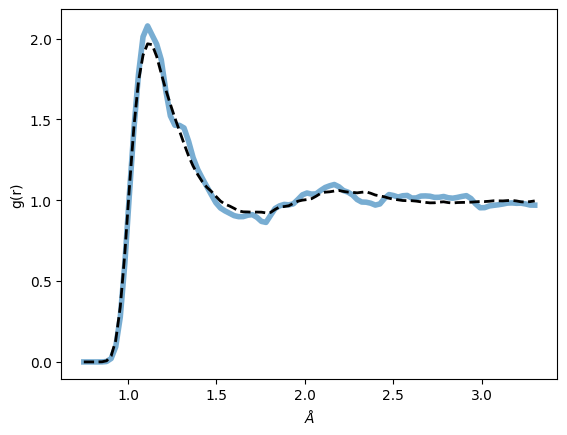

prior:  LJFamily()


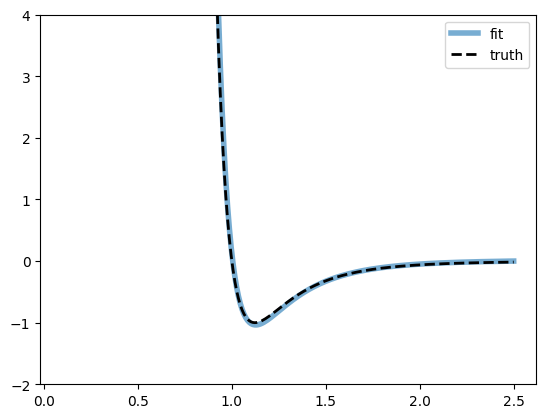

loss.grad_fn: <MulBackward0 object at 0x32354f3d0>
Sigma grad: tensor([0.0583])
Epsilon grad: tensor([0.0039])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.043955057859420776 0.0016104632522910833
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32354f3d0>
loss.grad_fn: <MulBackward0 object at 0x3235787f0>
Sigma grad: tensor([0.0582])
Epsilon grad: tensor([0.0023])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.059326596558094025 0.0012156821321696043
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3233a0c10>
loss.grad_fn: <MulBackward0 object at 0x32338ad30>
Sigma grad: tensor([0.1647])
Epsilon grad: tensor([0.0054])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

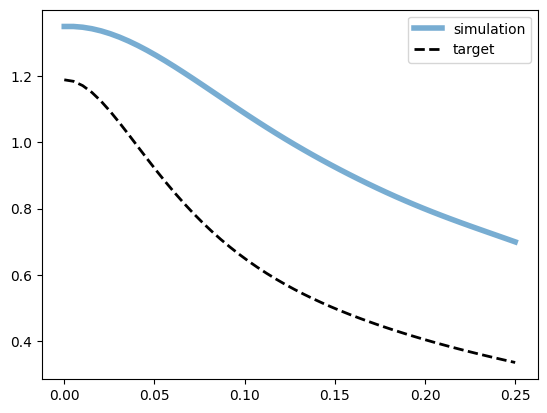

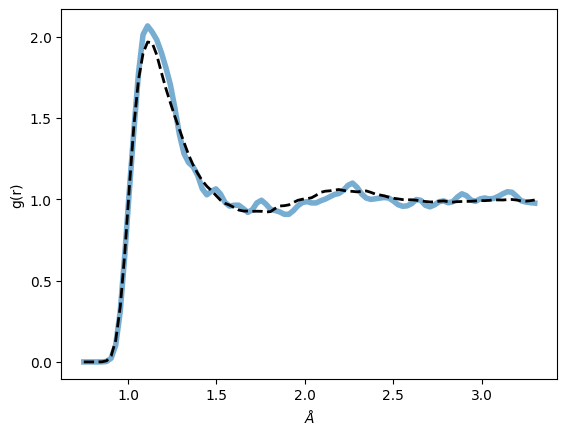

prior:  LJFamily()


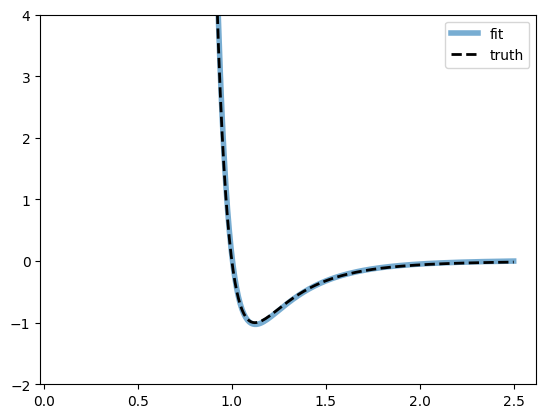

loss.grad_fn: <MulBackward0 object at 0x3233960d0>
Sigma grad: tensor([0.0489])
Epsilon grad: tensor([0.0052])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.14361482858657837 0.0016743693267926574
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322474070>
loss.grad_fn: <MulBackward0 object at 0x32354f3d0>
Sigma grad: tensor([-0.0188])
Epsilon grad: tensor([0.0019])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05790875852108002 0.0014259698800742626
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322474070>
loss.grad_fn: <MulBackward0 object at 0x309646f70>
Sigma grad: tensor([0.0170])
Epsilon grad: tensor([0.0089])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

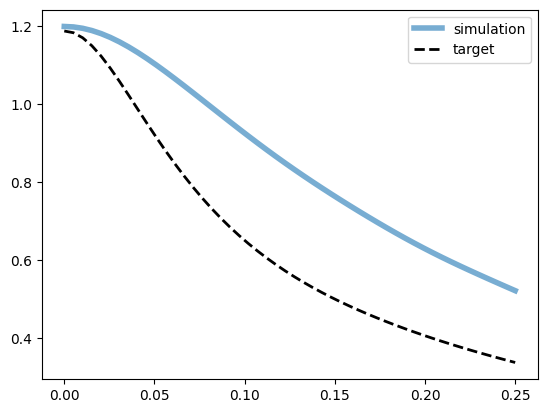

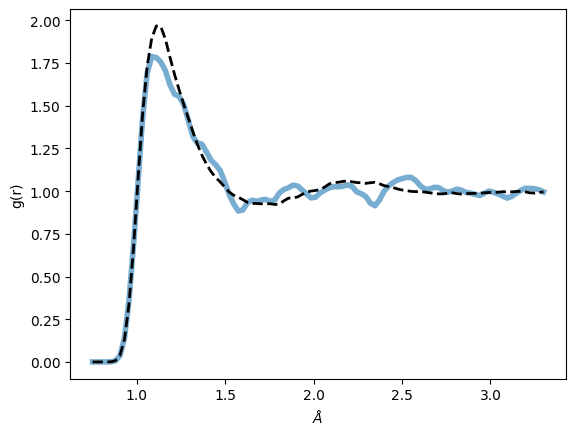

prior:  LJFamily()


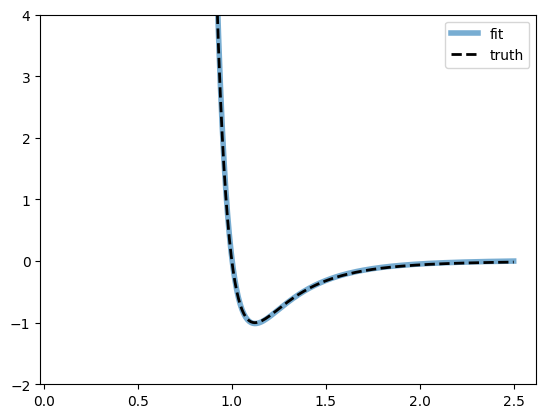

loss.grad_fn: <MulBackward0 object at 0x32266d2e0>
Sigma grad: tensor([-0.0533])
Epsilon grad: tensor([-0.0068])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.048498477786779404 0.0033197449520230293
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a215b0>
loss.grad_fn: <MulBackward0 object at 0x322474070>
Sigma grad: tensor([-0.1174])
Epsilon grad: tensor([-0.0046])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.02474144846200943 0.0014748141402378678
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3235a0700>
loss.grad_fn: <MulBackward0 object at 0x3235b40a0>
Sigma grad: tensor([-0.0717])
Epsilon grad: tensor([-0.0037])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon 

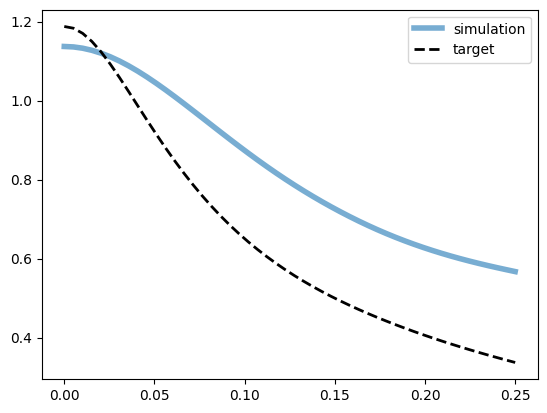

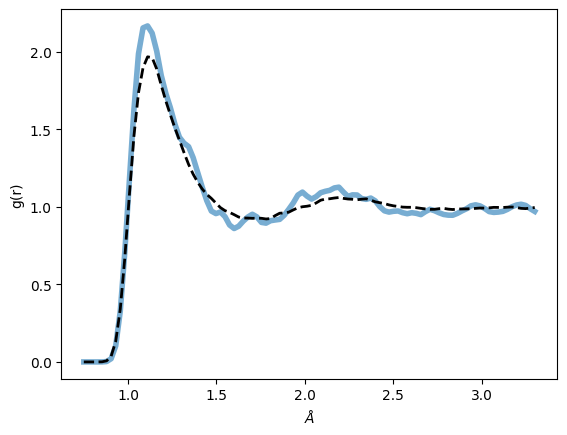

prior:  LJFamily()


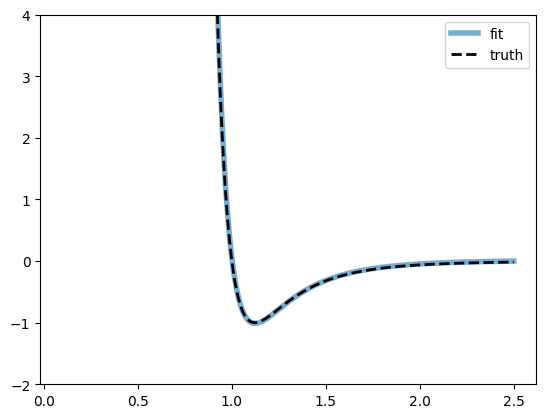

loss.grad_fn: <MulBackward0 object at 0x3235dc4c0>
Sigma grad: tensor([-0.0211])
Epsilon grad: tensor([0.0062])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03817226365208626 0.004022055771201849
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322f36c10>
loss.grad_fn: <MulBackward0 object at 0x32359e700>
Sigma grad: tensor([-0.0356])
Epsilon grad: tensor([0.0040])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06582929193973541 0.0022077858448028564
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x309689100>
loss.grad_fn: <MulBackward0 object at 0x32359e700>
Sigma grad: tensor([-0.0116])
Epsilon grad: tensor([-0.0002])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

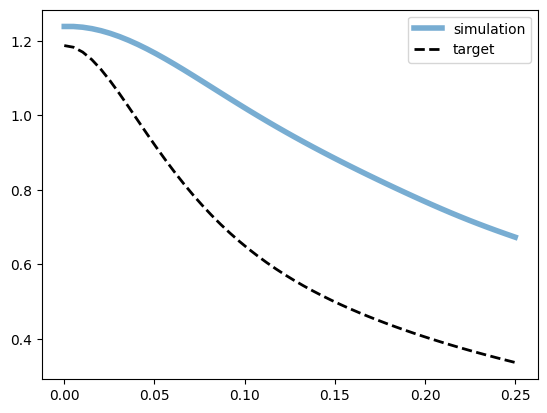

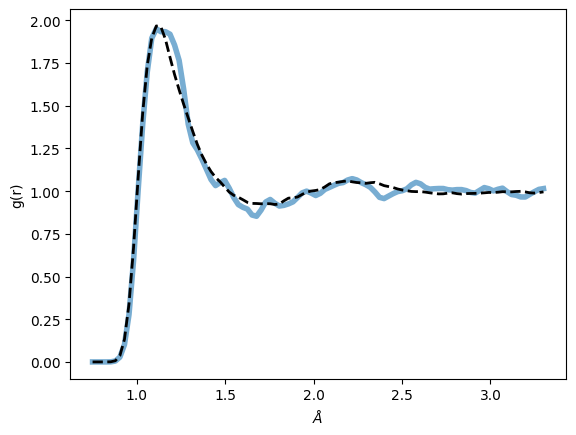

prior:  LJFamily()


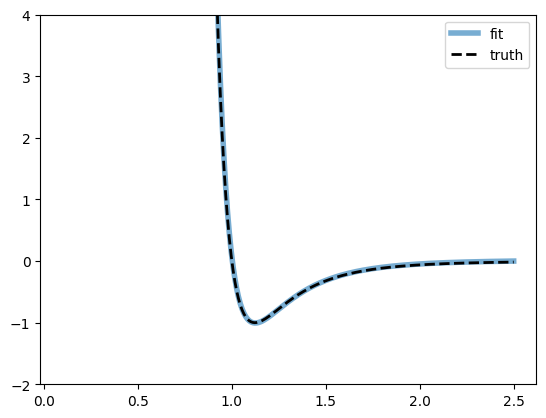

loss.grad_fn: <MulBackward0 object at 0x3221cf9d0>
Sigma grad: tensor([0.1024])
Epsilon grad: tensor([0.0039])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.106318399310112 0.001885987468995154
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322869160>
loss.grad_fn: <MulBackward0 object at 0x309689100>
Sigma grad: tensor([0.0901])
Epsilon grad: tensor([-0.0010])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05026410520076752 0.0031282042618840933
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x309689100>
loss.grad_fn: <MulBackward0 object at 0x322654f10>
Sigma grad: tensor([0.0276])
Epsilon grad: tensor([-0.0020])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn:

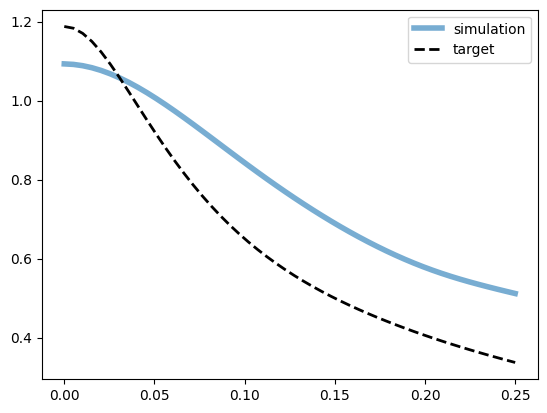

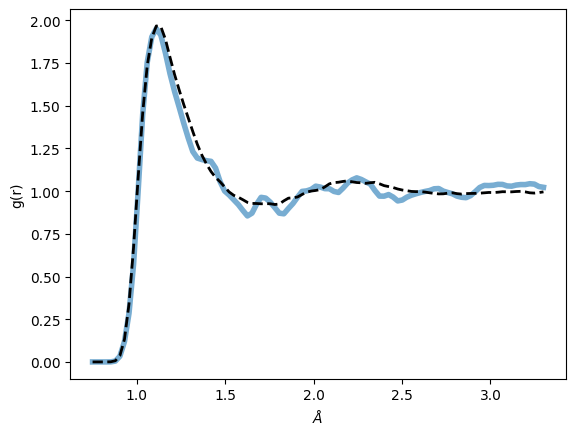

prior:  LJFamily()


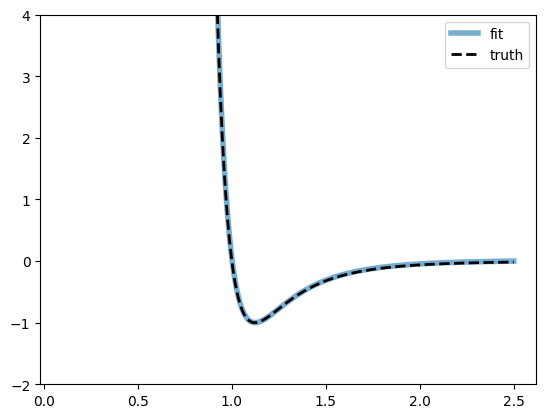

loss.grad_fn: <MulBackward0 object at 0x30b0eeaf0>
Sigma grad: tensor([-0.0014])
Epsilon grad: tensor([-0.0005])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.025547657161951065 0.0021228455007076263
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32345d3a0>
loss.grad_fn: <MulBackward0 object at 0x322869820>
Sigma grad: tensor([0.0157])
Epsilon grad: tensor([-0.0036])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.029906658455729485 0.0021505786571651697
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323456820>
loss.grad_fn: <MulBackward0 object at 0x3221c9fa0>
Sigma grad: tensor([-0.1796])
Epsilon grad: tensor([-0.0021])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon 

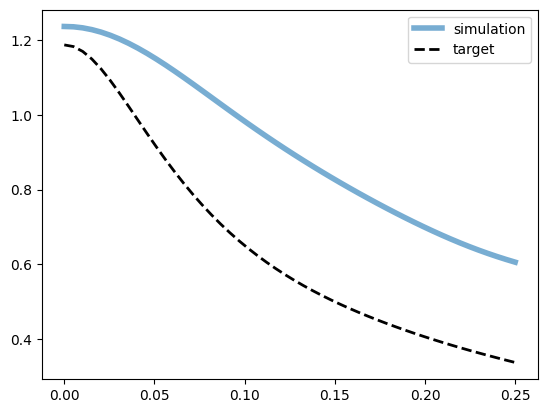

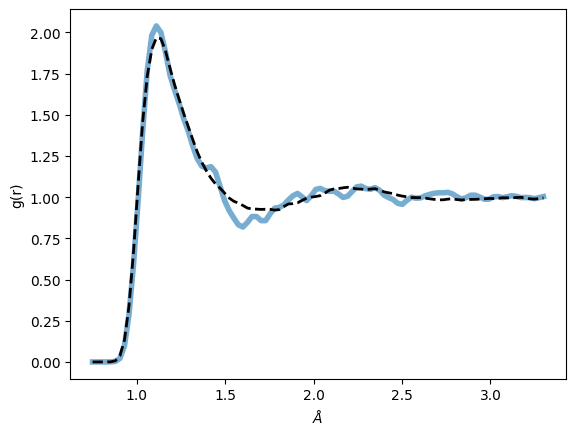

prior:  LJFamily()


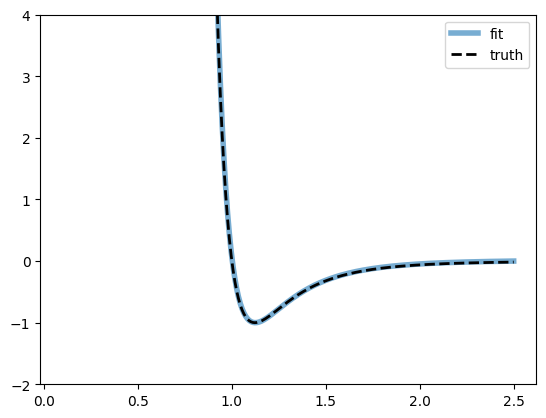

loss.grad_fn: <MulBackward0 object at 0x3231a33d0>
Sigma grad: tensor([0.0646])
Epsilon grad: tensor([0.0036])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0780290812253952 0.0017061525722965598
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3231a3370>
loss.grad_fn: <MulBackward0 object at 0x30b7e92b0>
Sigma grad: tensor([-0.0639])
Epsilon grad: tensor([-0.0007])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03643809258937836 0.0014200886944308877
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323182100>
loss.grad_fn: <MulBackward0 object at 0x30b7e92b0>
Sigma grad: tensor([0.0292])
Epsilon grad: tensor([0.0053])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

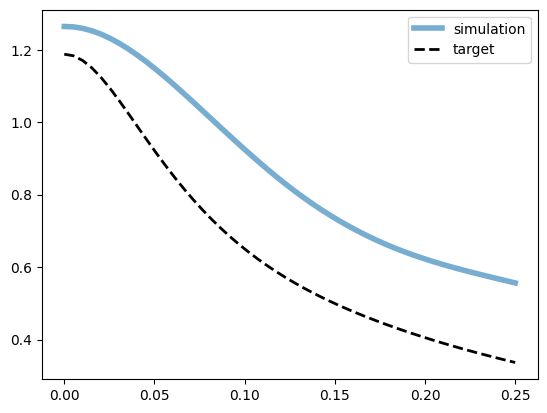

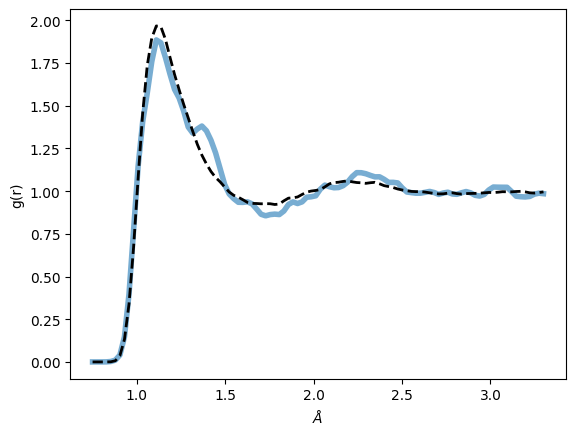

prior:  LJFamily()


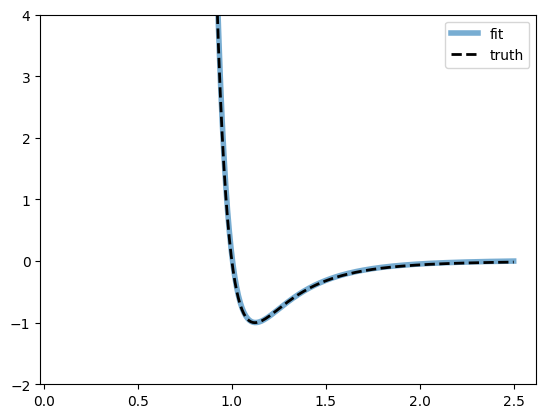

loss.grad_fn: <MulBackward0 object at 0x3231a3370>
Sigma grad: tensor([-0.0545])
Epsilon grad: tensor([-0.0066])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05071740970015526 0.003170482814311981
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3231a3370>
loss.grad_fn: <MulBackward0 object at 0x309646a30>
Sigma grad: tensor([0.0296])
Epsilon grad: tensor([-0.0005])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05313902720808983 0.0010495223104953766
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3228c1730>
loss.grad_fn: <MulBackward0 object at 0x309646a30>
Sigma grad: tensor([0.0720])
Epsilon grad: tensor([0.0029])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

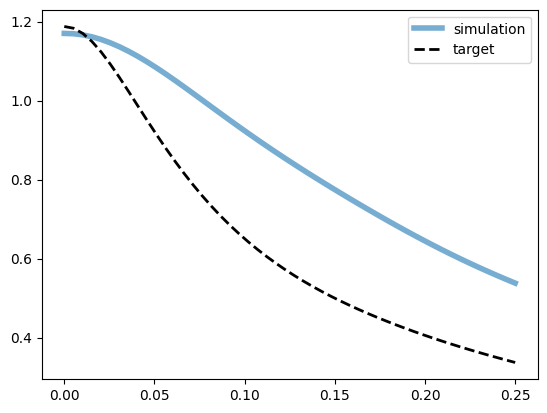

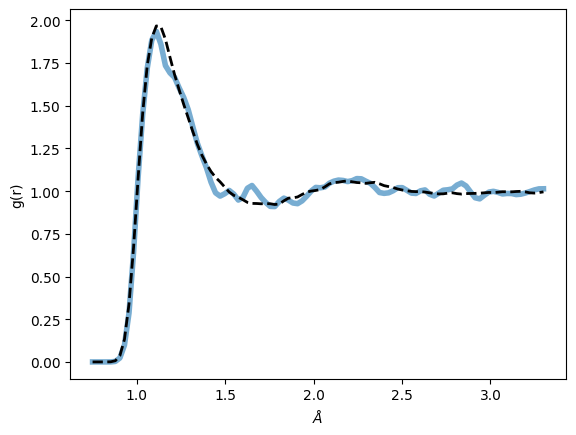

prior:  LJFamily()


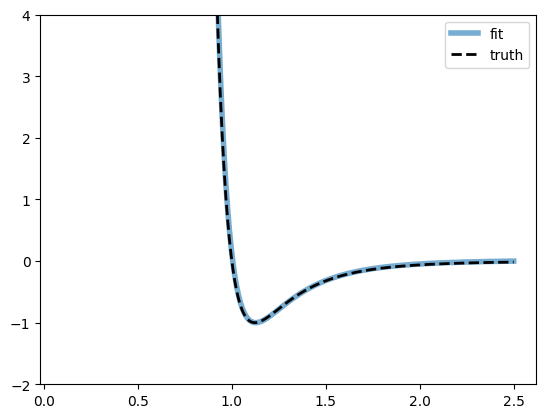

loss.grad_fn: <MulBackward0 object at 0x3228c1eb0>
Sigma grad: tensor([-0.0024])
Epsilon grad: tensor([-0.0015])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.050353627651929855 0.001303051132708788
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323514be0>
loss.grad_fn: <MulBackward0 object at 0x3231a3e50>
Sigma grad: tensor([0.0883])
Epsilon grad: tensor([-0.0001])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0565471425652504 0.0016376000130549073
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3231a3e50>
loss.grad_fn: <MulBackward0 object at 0x3223eb4f0>
Sigma grad: tensor([0.0033])
Epsilon grad: tensor([0.0005])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

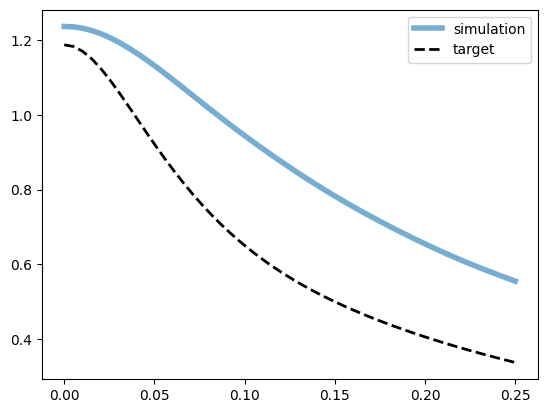

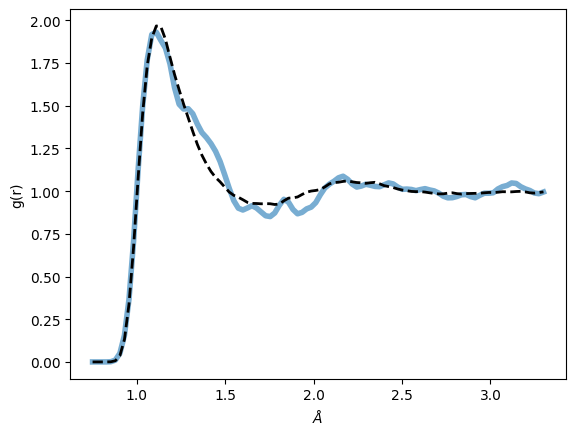

prior:  LJFamily()


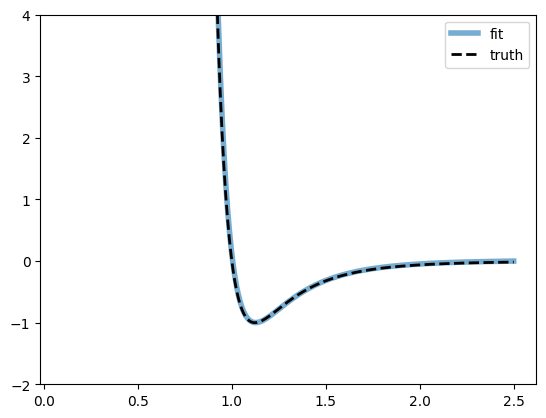

loss.grad_fn: <MulBackward0 object at 0x3223eb4f0>
Sigma grad: tensor([-0.0358])
Epsilon grad: tensor([-0.0025])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.058946263045072556 0.002687194151803851
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32350df10>
loss.grad_fn: <MulBackward0 object at 0x3231a3e50>
Sigma grad: tensor([0.0887])
Epsilon grad: tensor([0.0013])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06510306149721146 0.0025668737944215536
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323558fd0>
loss.grad_fn: <MulBackward0 object at 0x3231a3e50>
Sigma grad: tensor([-0.0090])
Epsilon grad: tensor([-0.0045])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

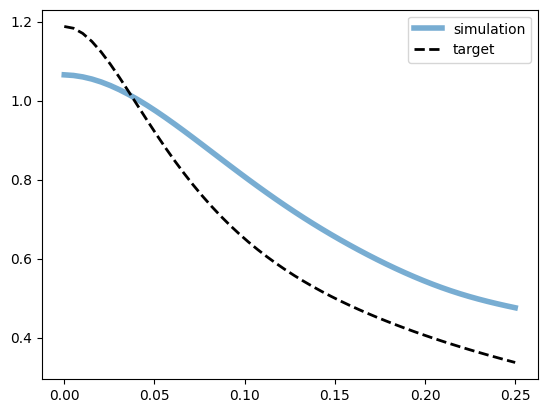

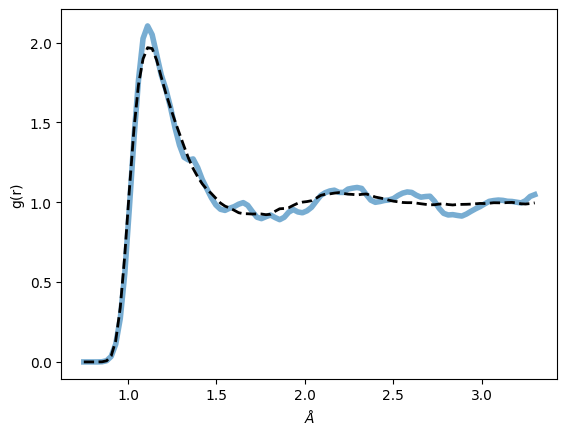

prior:  LJFamily()


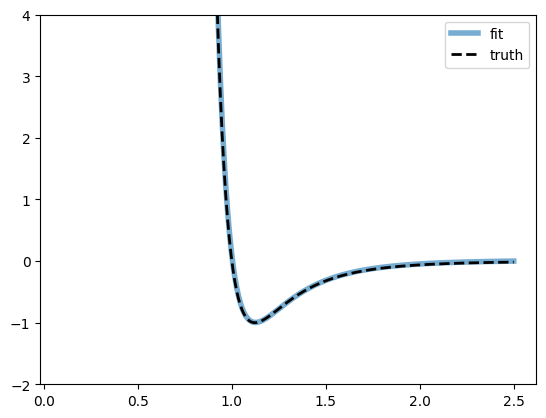

loss.grad_fn: <MulBackward0 object at 0x309646670>
Sigma grad: tensor([0.0827])
Epsilon grad: tensor([0.0053])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.01724628359079361 0.002091265982016921
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x309646670>
loss.grad_fn: <MulBackward0 object at 0x322f23dc0>
Sigma grad: tensor([0.0898])
Epsilon grad: tensor([0.0054])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05258636921644211 0.002404746599495411
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32350df10>
loss.grad_fn: <MulBackward0 object at 0x32315a0d0>
Sigma grad: tensor([-0.1659])
Epsilon grad: tensor([-0.0020])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn

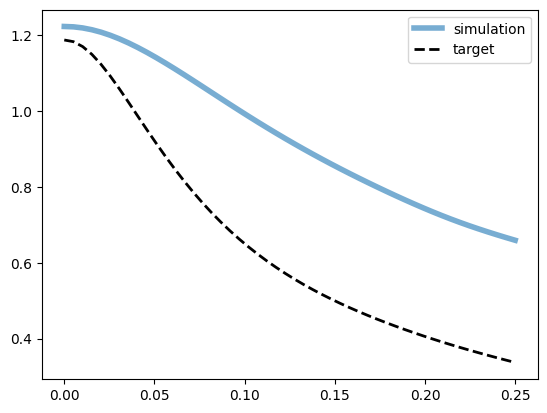

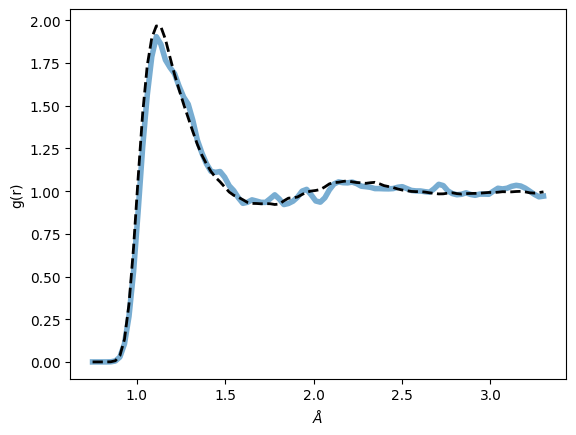

prior:  LJFamily()


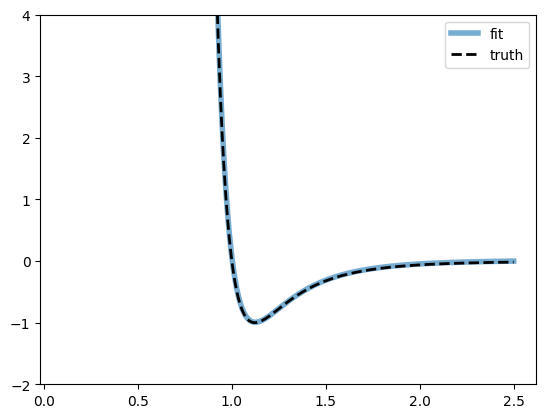

loss.grad_fn: <MulBackward0 object at 0x32340e940>
Sigma grad: tensor([0.1438])
Epsilon grad: tensor([2.2163e-05])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.09109357744455338 0.0024319577496498823
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32340e940>
loss.grad_fn: <MulBackward0 object at 0x32350d4c0>
Sigma grad: tensor([-0.0736])
Epsilon grad: tensor([-0.0028])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06270141899585724 0.0014994958182796836
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323373850>
loss.grad_fn: <MulBackward0 object at 0x32351fe80>
Sigma grad: tensor([0.0554])
Epsilon grad: tensor([0.0007])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon g

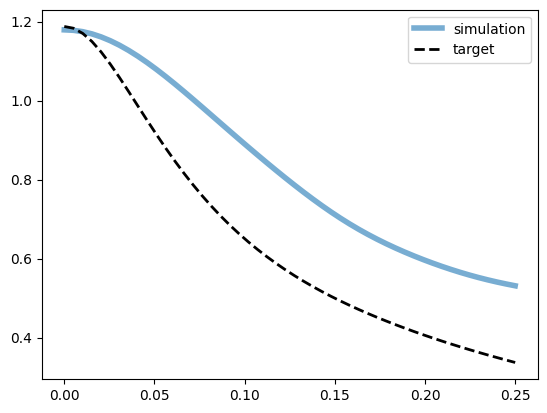

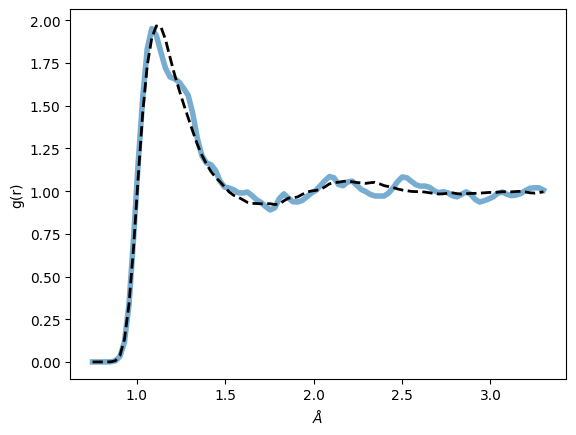

prior:  LJFamily()


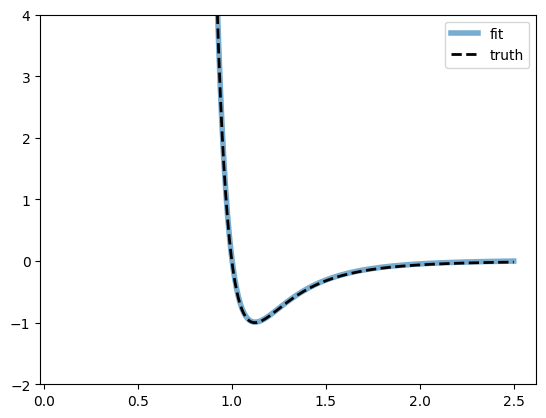

loss.grad_fn: <MulBackward0 object at 0x32351fb80>
Sigma grad: tensor([-0.0447])
Epsilon grad: tensor([-0.0025])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.036032870411872864 0.002254665829241276
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32359e040>
loss.grad_fn: <MulBackward0 object at 0x32350d4c0>
Sigma grad: tensor([0.0616])
Epsilon grad: tensor([0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04116406291723251 0.00222739577293396
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322e289a0>
loss.grad_fn: <MulBackward0 object at 0x323373850>
Sigma grad: tensor([0.0045])
Epsilon grad: tensor([0.0059])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn

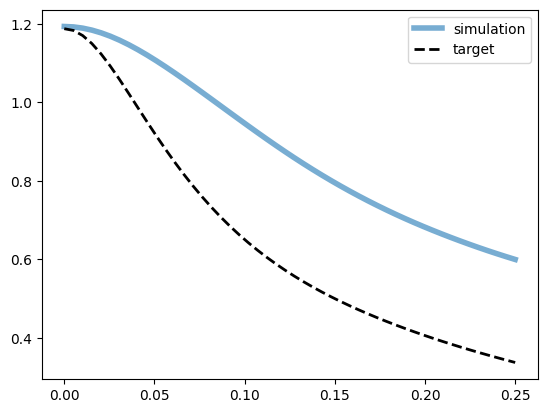

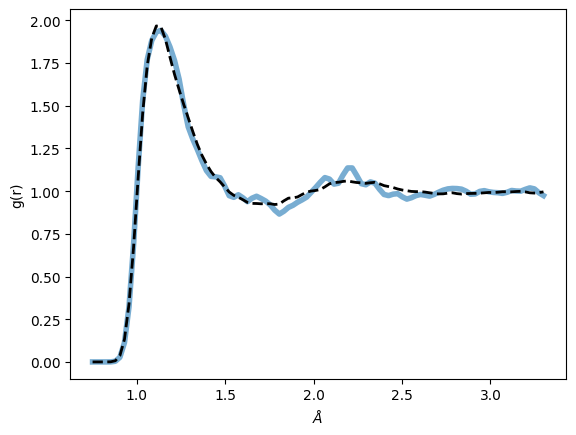

prior:  LJFamily()


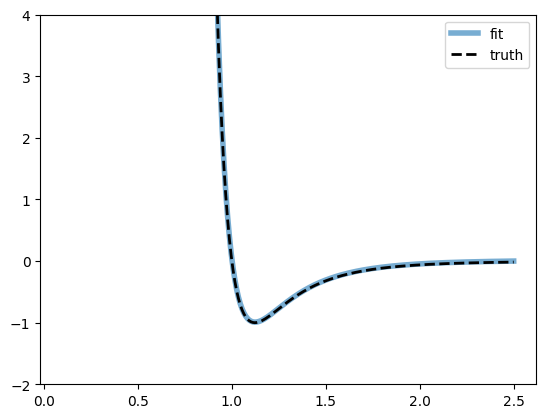

loss.grad_fn: <MulBackward0 object at 0x322e289a0>
Sigma grad: tensor([-0.0247])
Epsilon grad: tensor([0.0001])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06347573548555374 0.0010188031010329723
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322e289a0>
loss.grad_fn: <MulBackward0 object at 0x322e45cd0>
Sigma grad: tensor([-0.1287])
Epsilon grad: tensor([-7.6834e-05])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04298504814505577 0.0022903624922037125
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323361550>
loss.grad_fn: <MulBackward0 object at 0x3231877f0>
Sigma grad: tensor([-0.0951])
Epsilon grad: tensor([0.0054])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon

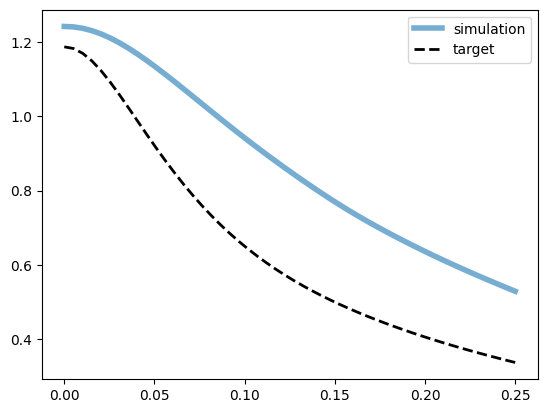

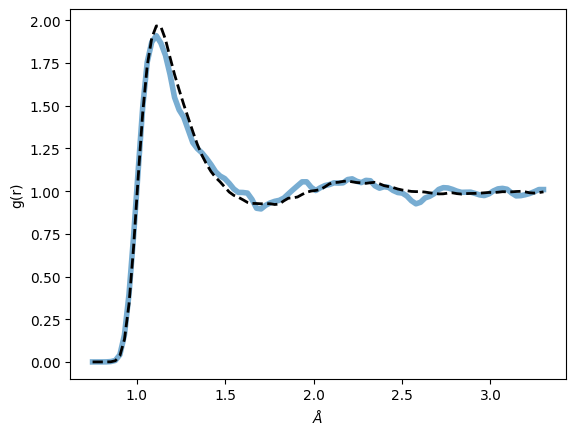

prior:  LJFamily()


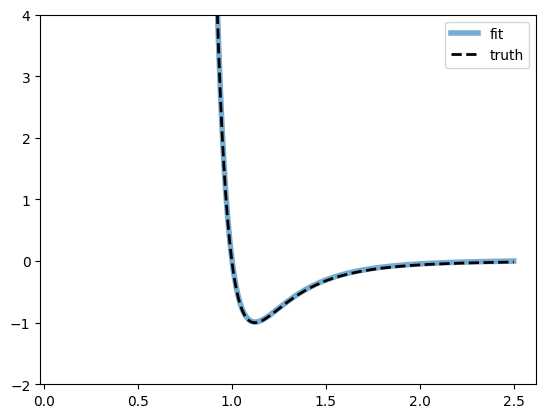

loss.grad_fn: <MulBackward0 object at 0x322afa820>
Sigma grad: tensor([-0.1153])
Epsilon grad: tensor([-0.0060])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.054891761392354965 0.001530307694338262
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32212bee0>
loss.grad_fn: <MulBackward0 object at 0x322e32d00>
Sigma grad: tensor([-0.0196])
Epsilon grad: tensor([-0.0023])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05692648887634277 0.001130678690969944
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322e32d00>
loss.grad_fn: <MulBackward0 object at 0x322aca6d0>
Sigma grad: tensor([-0.0927])
Epsilon grad: tensor([0.0017])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gra

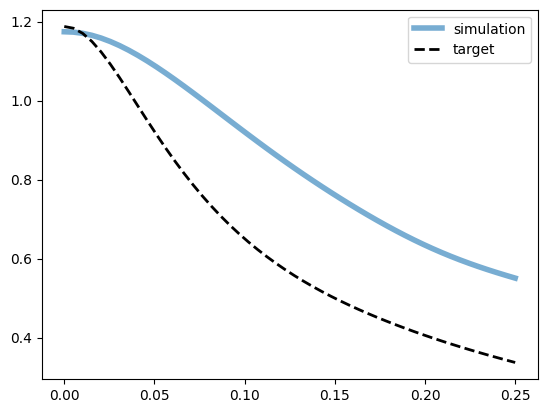

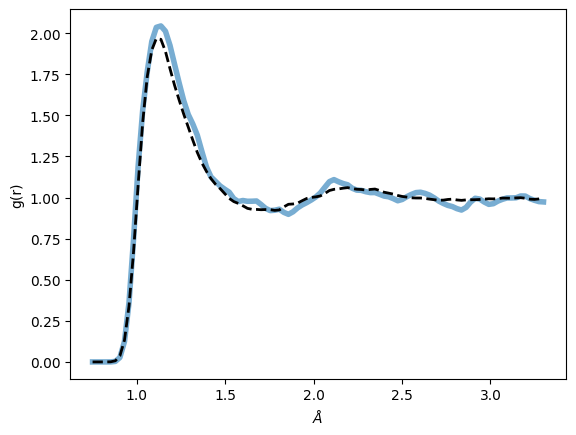

prior:  LJFamily()


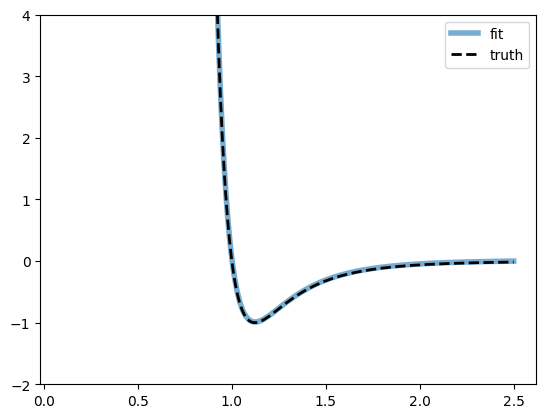

loss.grad_fn: <MulBackward0 object at 0x322de2790>
Sigma grad: tensor([0.0004])
Epsilon grad: tensor([0.0026])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.048206642270088196 0.001989241223782301
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322de2790>
loss.grad_fn: <MulBackward0 object at 0x322afa820>
Sigma grad: tensor([-0.1205])
Epsilon grad: tensor([0.0013])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03628047928214073 0.0027396075893193483
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322afa820>
loss.grad_fn: <MulBackward0 object at 0x3227e1d90>
Sigma grad: tensor([0.0544])
Epsilon grad: tensor([-0.0001])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

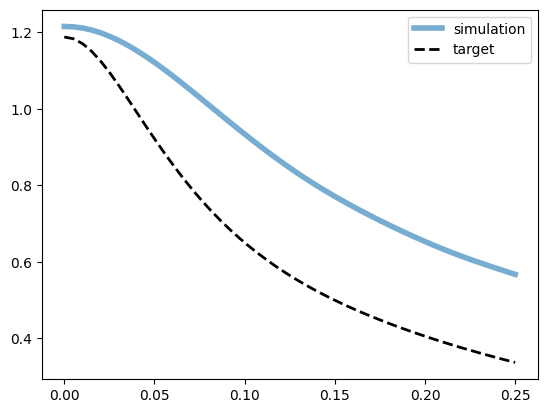

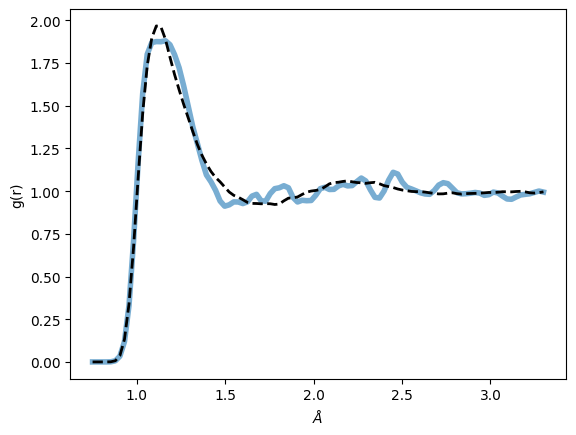

prior:  LJFamily()


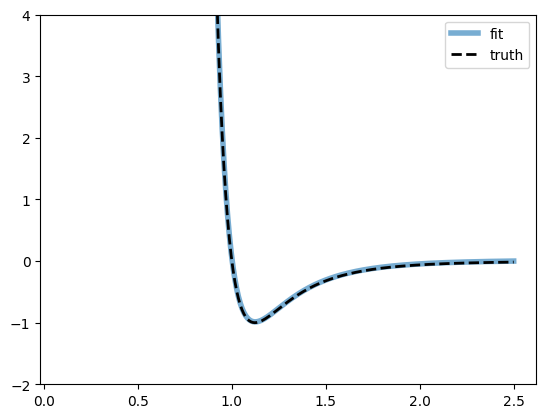

loss.grad_fn: <MulBackward0 object at 0x323578b20>
Sigma grad: tensor([-0.0410])
Epsilon grad: tensor([-0.0017])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05578653886914253 0.0025210052262991667
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322141130>
loss.grad_fn: <MulBackward0 object at 0x323396cd0>
Sigma grad: tensor([-0.0535])
Epsilon grad: tensor([-0.0041])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.11057775467634201 0.0016772982198745012
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323396cd0>
loss.grad_fn: <MulBackward0 object at 0x3228d3a00>
Sigma grad: tensor([0.0410])
Epsilon grad: tensor([-0.0008])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

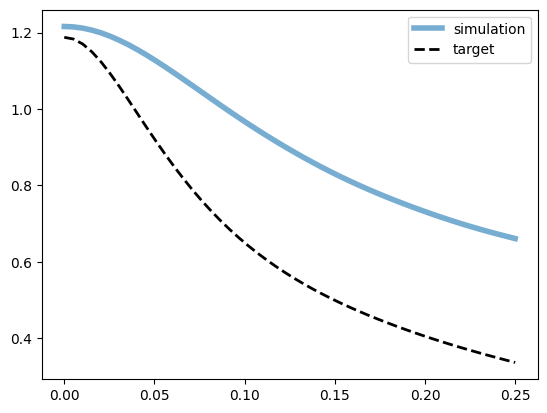

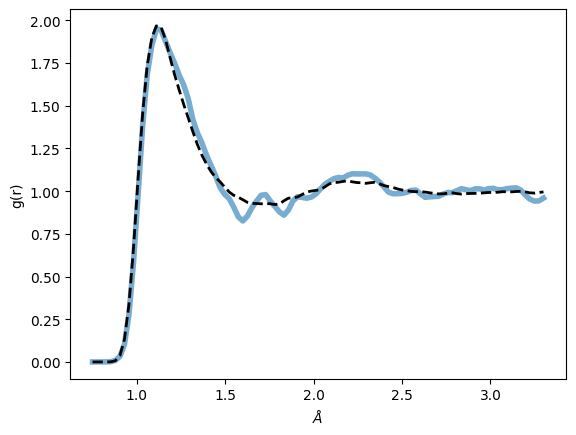

prior:  LJFamily()


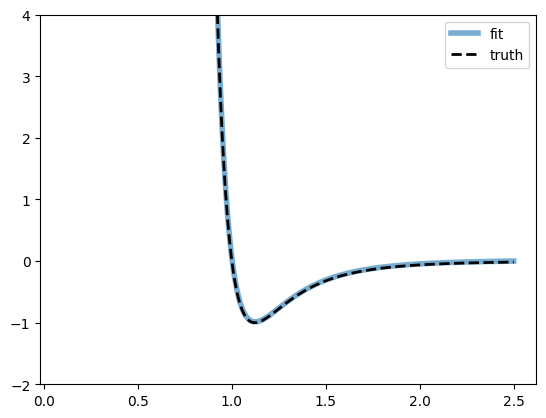

loss.grad_fn: <MulBackward0 object at 0x30b7aba00>
Sigma grad: tensor([0.1169])
Epsilon grad: tensor([0.0024])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.08166081458330154 0.0019374265102669597
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32213d670>
loss.grad_fn: <MulBackward0 object at 0x3226bcf40>
Sigma grad: tensor([-0.0508])
Epsilon grad: tensor([0.0052])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.029849279671907425 0.0023239850997924805
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3221305b0>
loss.grad_fn: <MulBackward0 object at 0x30b07ad00>
Sigma grad: tensor([-0.0077])
Epsilon grad: tensor([0.0043])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

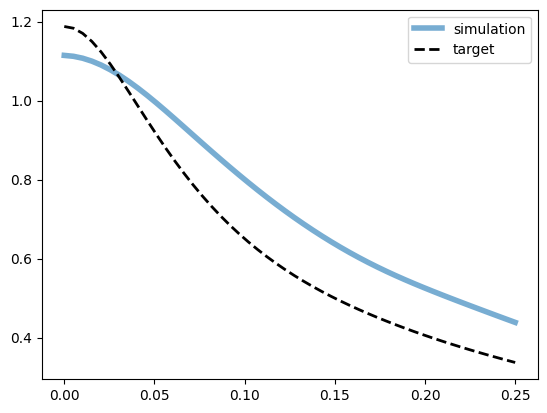

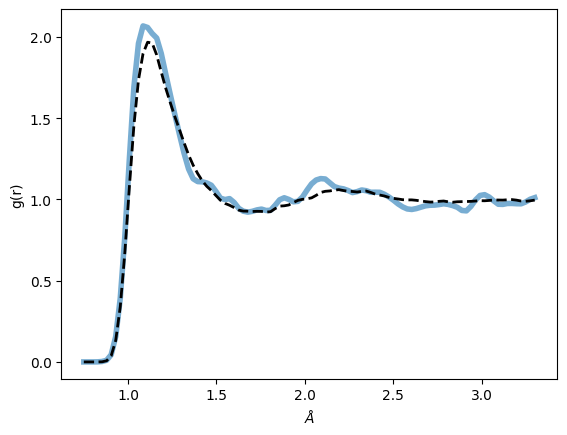

prior:  LJFamily()


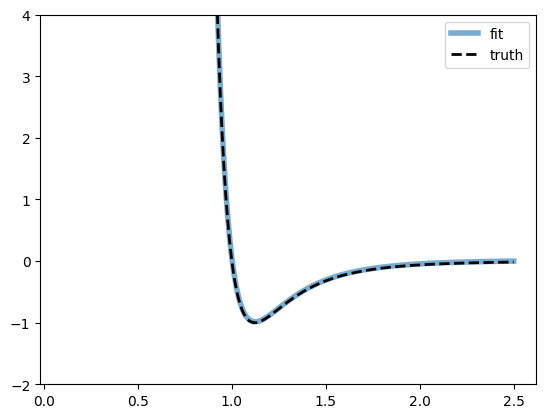

loss.grad_fn: <MulBackward0 object at 0x322783310>
Sigma grad: tensor([-0.1376])
Epsilon grad: tensor([0.0019])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.01364127267152071 0.003270469605922699
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322d84dc0>
loss.grad_fn: <MulBackward0 object at 0x32217a760>
Sigma grad: tensor([0.0231])
Epsilon grad: tensor([0.0065])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.039452411234378815 0.002575026825070381
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32217a760>
loss.grad_fn: <MulBackward0 object at 0x3221305b0>
Sigma grad: tensor([0.0014])
Epsilon grad: tensor([0.0084])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn

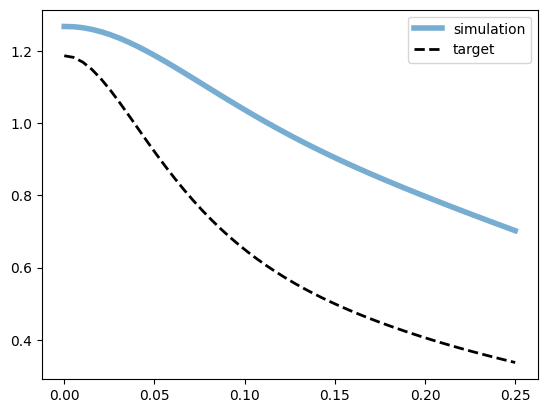

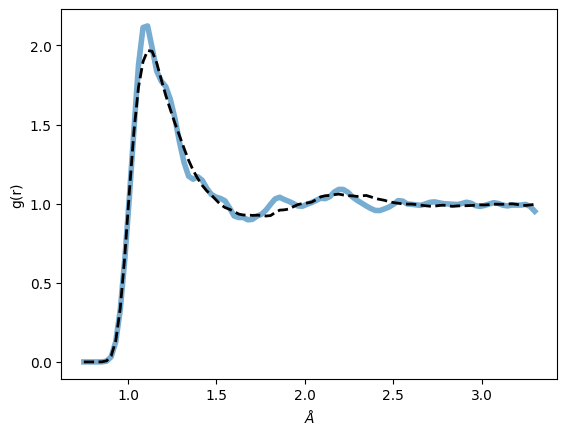

prior:  LJFamily()


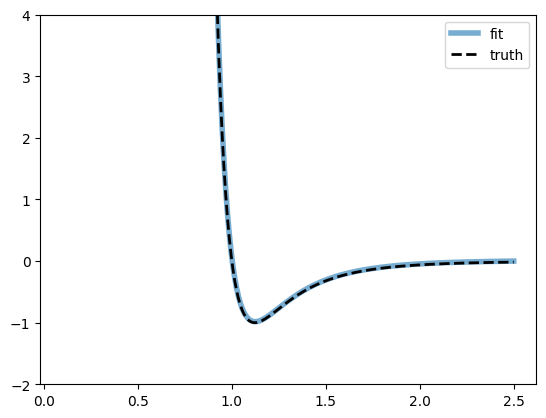

loss.grad_fn: <MulBackward0 object at 0x320d459a0>
Sigma grad: tensor([-0.0135])
Epsilon grad: tensor([0.0040])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.12119416892528534 0.002000699285417795
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322ec7490>
loss.grad_fn: <MulBackward0 object at 0x322a21190>
Sigma grad: tensor([0.0005])
Epsilon grad: tensor([-0.0003])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04404604062438011 0.0012938278960064054
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3235a0e50>
loss.grad_fn: <MulBackward0 object at 0x320d459a0>
Sigma grad: tensor([0.1738])
Epsilon grad: tensor([0.0018])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

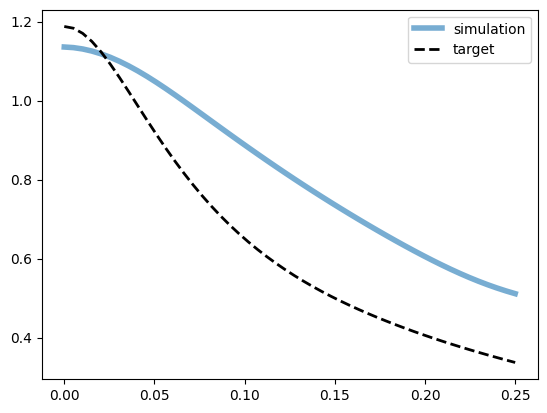

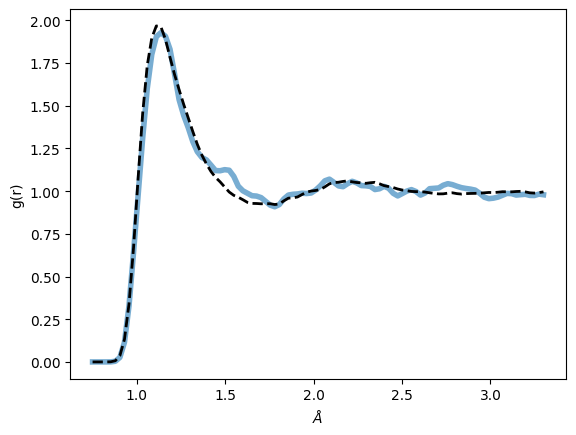

prior:  LJFamily()


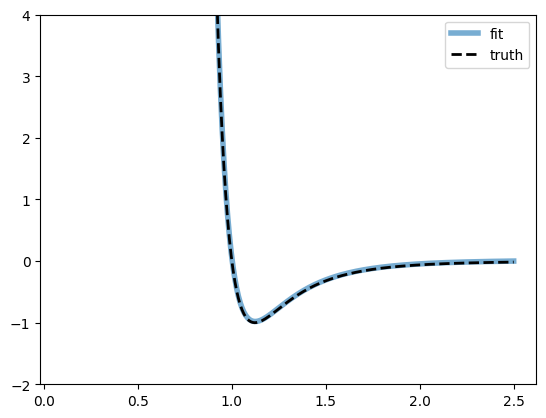

loss.grad_fn: <MulBackward0 object at 0x322713cd0>
Sigma grad: tensor([0.0451])
Epsilon grad: tensor([-0.0009])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03637535125017166 0.0018167458474636078
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x323140970>
loss.grad_fn: <MulBackward0 object at 0x322ec7490>
Sigma grad: tensor([-0.0282])
Epsilon grad: tensor([-0.0026])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0620318166911602 0.0014666217612102628
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x320d71190>
loss.grad_fn: <MulBackward0 object at 0x3235bb910>
Sigma grad: tensor([0.0196])
Epsilon grad: tensor([-0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

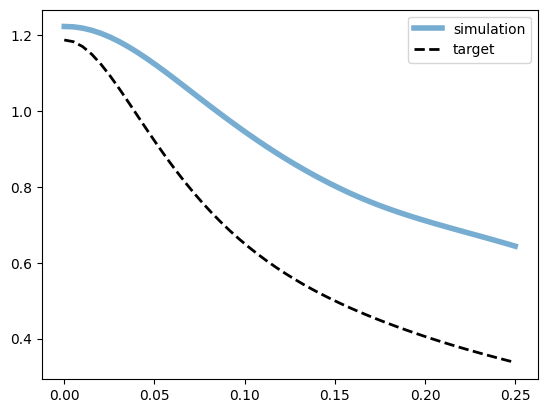

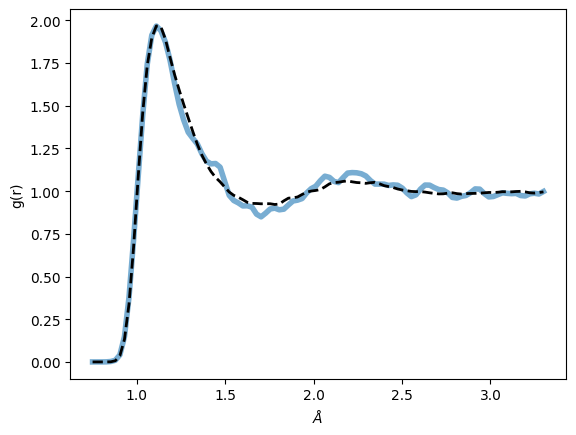

prior:  LJFamily()


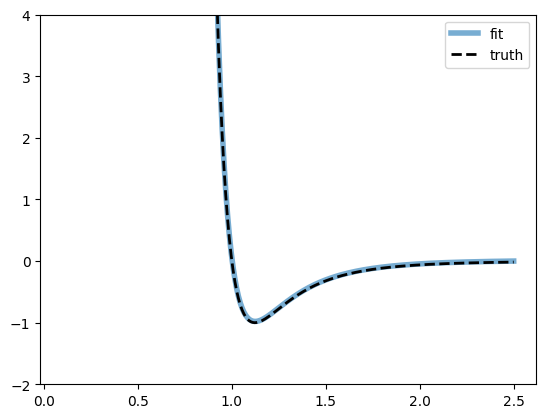

loss.grad_fn: <MulBackward0 object at 0x323140970>
Sigma grad: tensor([-0.0225])
Epsilon grad: tensor([-0.0012])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.07176496833562851 0.0011180959409102798
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a061c0>
loss.grad_fn: <MulBackward0 object at 0x322f77130>
Sigma grad: tensor([0.0923])
Epsilon grad: tensor([-0.0024])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.11187832057476044 0.0036347638815641403
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322f77130>
loss.grad_fn: <MulBackward0 object at 0x30a7c24c0>
Sigma grad: tensor([-0.0839])
Epsilon grad: tensor([-0.0030])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

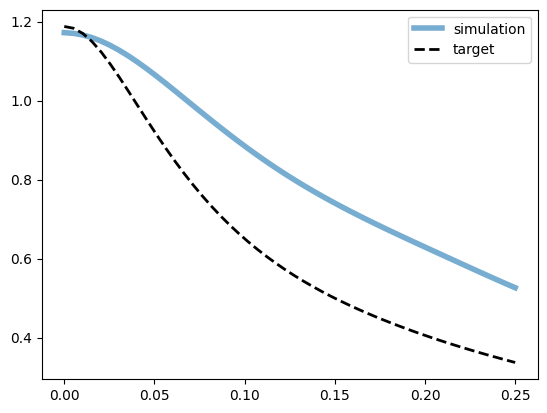

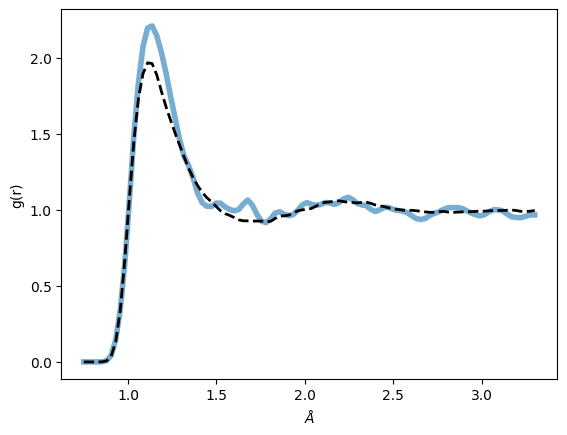

prior:  LJFamily()


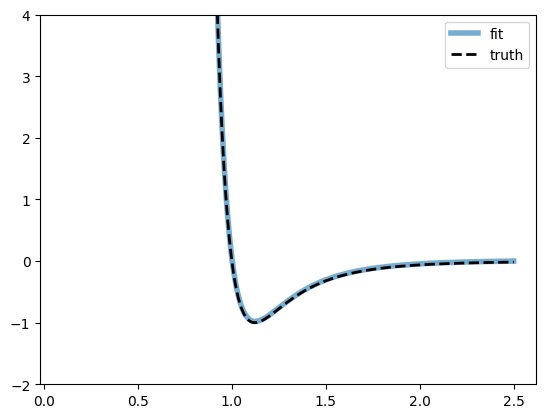

loss.grad_fn: <MulBackward0 object at 0x3224fc880>
Sigma grad: tensor([0.1161])
Epsilon grad: tensor([0.0122])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03998543322086334 0.004850930068641901
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322acb070>
loss.grad_fn: <MulBackward0 object at 0x32339b070>
Sigma grad: tensor([0.0446])
Epsilon grad: tensor([0.0119])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.013589046895503998 0.006552137900143862
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32339b070>
loss.grad_fn: <MulBackward0 object at 0x322acb070>
Sigma grad: tensor([0.0828])
Epsilon grad: tensor([0.0056])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn:

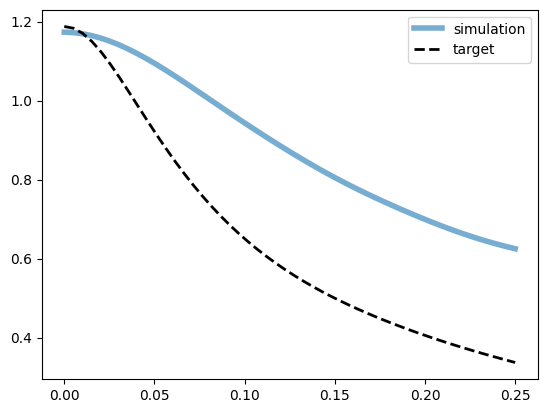

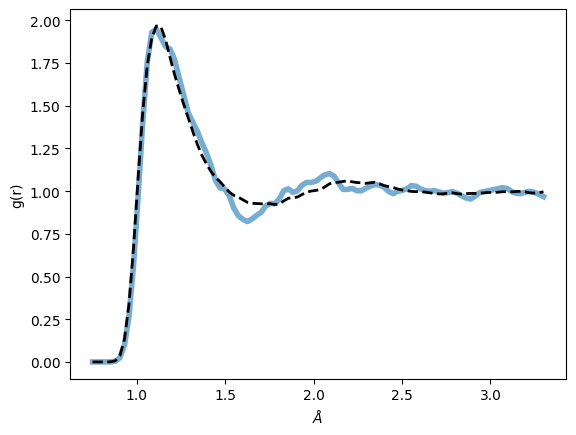

prior:  LJFamily()


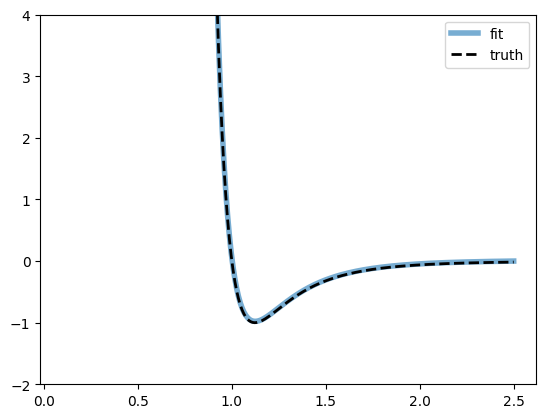

loss.grad_fn: <MulBackward0 object at 0x3231eb7c0>
Sigma grad: tensor([0.0800])
Epsilon grad: tensor([0.0027])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0666143000125885 0.0019779729191213846
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x30a7c24c0>
loss.grad_fn: <MulBackward0 object at 0x322a41790>
Sigma grad: tensor([-0.1039])
Epsilon grad: tensor([0.0017])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.08186768740415573 0.0028288031462579966
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3233d1fa0>
loss.grad_fn: <MulBackward0 object at 0x322bc58b0>
Sigma grad: tensor([0.0116])
Epsilon grad: tensor([-0.0016])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_f

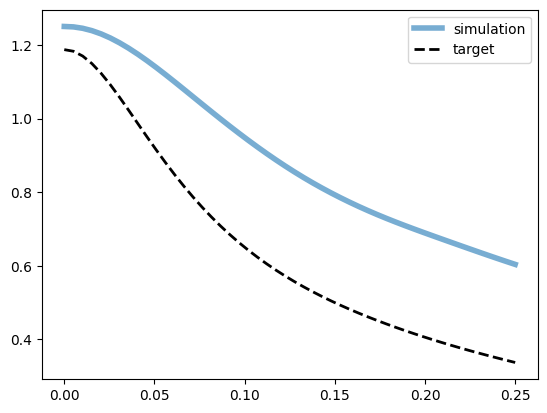

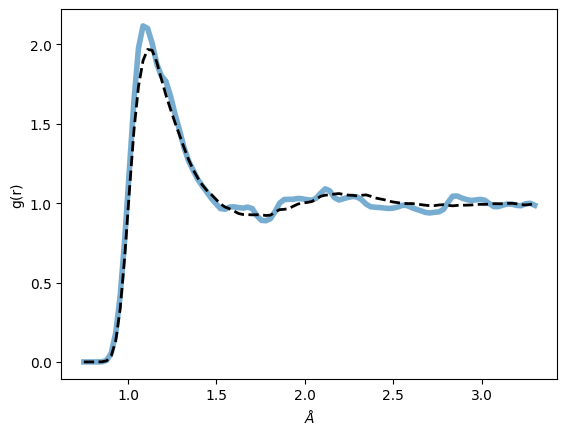

prior:  LJFamily()


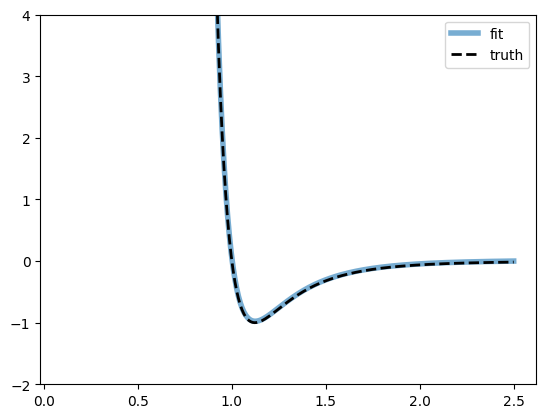

loss.grad_fn: <MulBackward0 object at 0x3234482e0>
Sigma grad: tensor([-0.1477])
Epsilon grad: tensor([0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.06775245815515518 0.0030104329343885183
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32312ba30>
loss.grad_fn: <MulBackward0 object at 0x30a97bf40>
Sigma grad: tensor([0.0099])
Epsilon grad: tensor([0.0026])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0359857901930809 0.001309901475906372
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32312ba30>
loss.grad_fn: <MulBackward0 object at 0x3233d1820>
Sigma grad: tensor([-0.0225])
Epsilon grad: tensor([-5.6896e-05])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

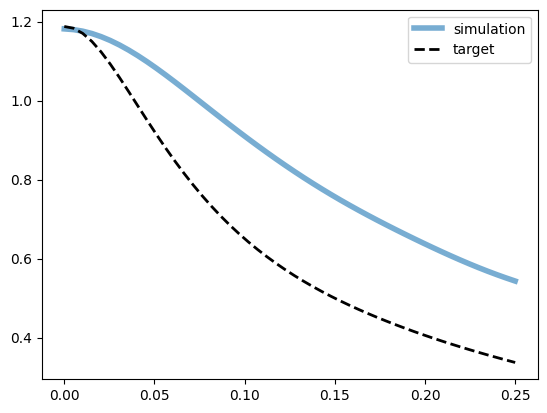

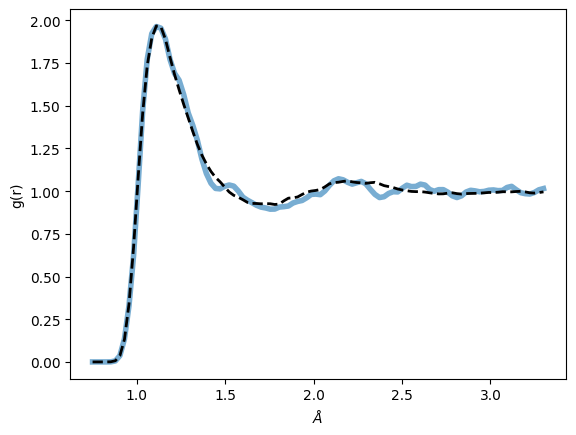

prior:  LJFamily()


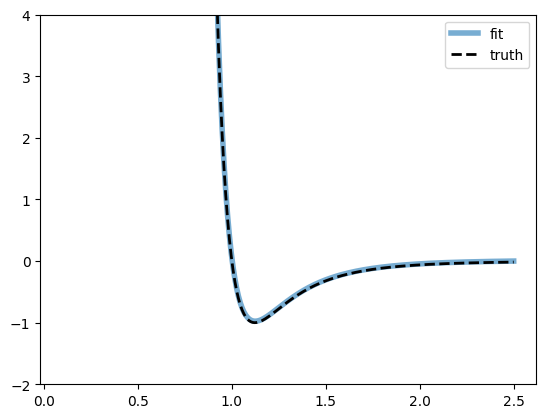

loss.grad_fn: <MulBackward0 object at 0x30a7dfbe0>
Sigma grad: tensor([0.0237])
Epsilon grad: tensor([0.0014])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04642429202795029 0.0008329626289196312
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x309679310>
loss.grad_fn: <MulBackward0 object at 0x30a7dfb20>
Sigma grad: tensor([-0.0180])
Epsilon grad: tensor([-0.0031])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.09798570722341537 0.0015375359216704965
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322825730>
loss.grad_fn: <MulBackward0 object at 0x309679310>
Sigma grad: tensor([0.0316])
Epsilon grad: tensor([-0.0025])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

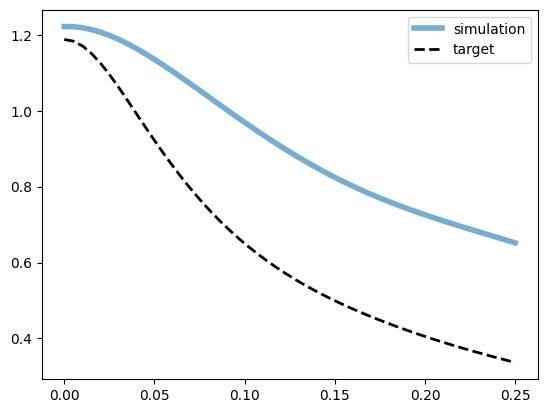

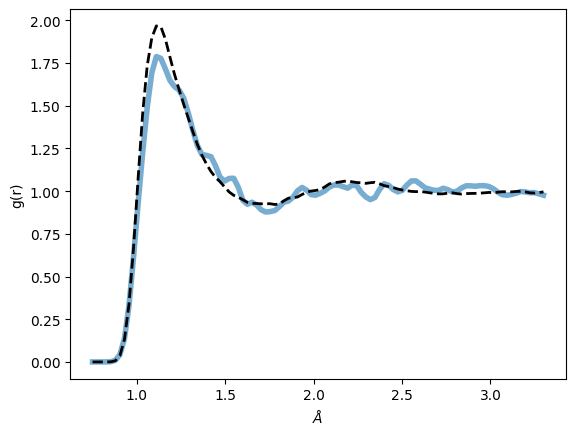

prior:  LJFamily()


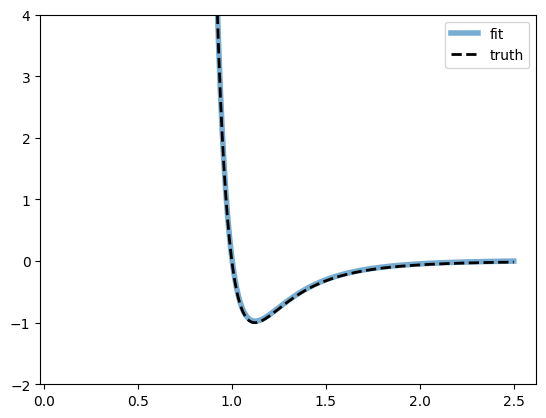

loss.grad_fn: <MulBackward0 object at 0x32286d2e0>
Sigma grad: tensor([0.0549])
Epsilon grad: tensor([-0.0059])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.08050700277090073 0.004129062872380018
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32290e070>
loss.grad_fn: <MulBackward0 object at 0x320dda700>
Sigma grad: tensor([-0.0932])
Epsilon grad: tensor([-0.0027])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04794678837060928 0.0025393865071237087
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x30a7dfbe0>
loss.grad_fn: <MulBackward0 object at 0x32355a100>
Sigma grad: tensor([0.0770])
Epsilon grad: tensor([0.0049])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

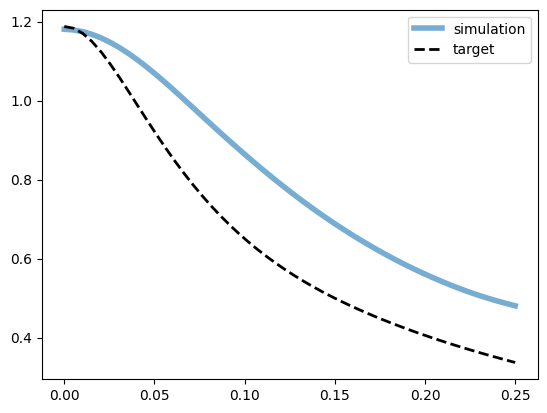

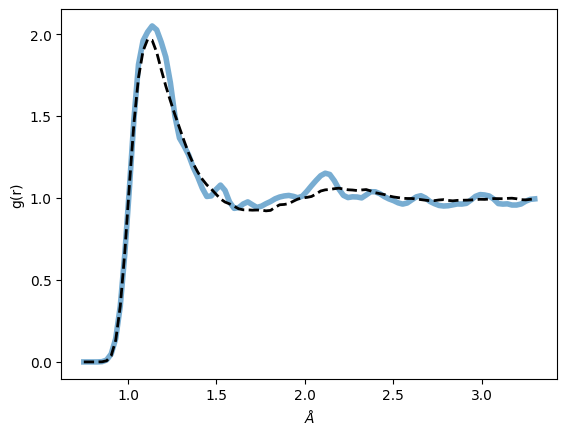

prior:  LJFamily()


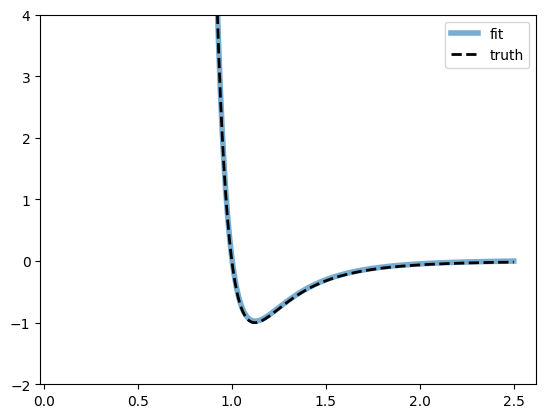

loss.grad_fn: <MulBackward0 object at 0x30a7dfbe0>
Sigma grad: tensor([0.0528])
Epsilon grad: tensor([0.0052])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.026926415041089058 0.002360723679885268
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x30a7dfbe0>
loss.grad_fn: <MulBackward0 object at 0x322841970>
Sigma grad: tensor([-0.0129])
Epsilon grad: tensor([0.0041])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.017940901219844818 0.0023643807508051395
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32286d2e0>
loss.grad_fn: <MulBackward0 object at 0x30a7dfbe0>
Sigma grad: tensor([0.0514])
Epsilon grad: tensor([0.0017])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

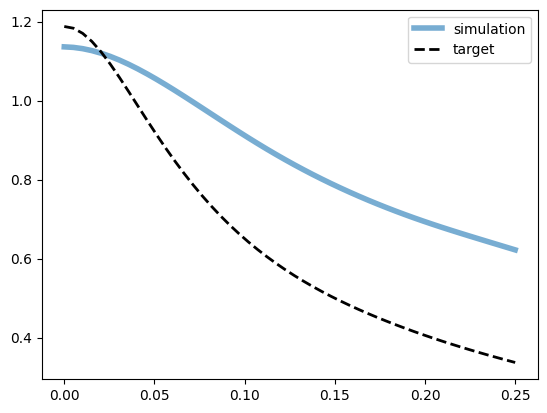

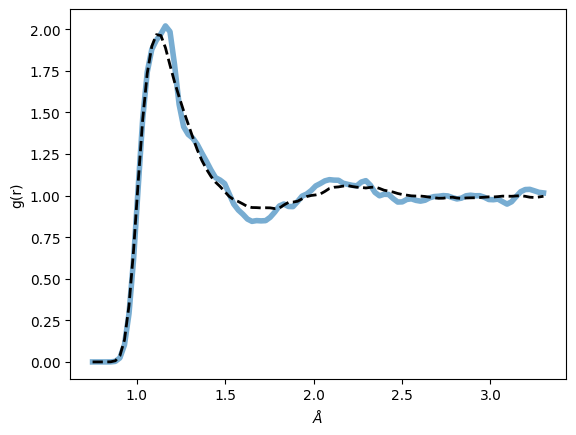

prior:  LJFamily()


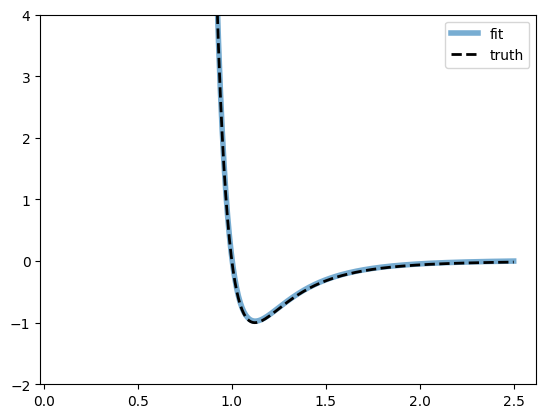

loss.grad_fn: <MulBackward0 object at 0x32286d2e0>
Sigma grad: tensor([0.0494])
Epsilon grad: tensor([0.0034])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.05817918851971626 0.0019665632862597704
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3223a2850>
loss.grad_fn: <MulBackward0 object at 0x322f4c820>
Sigma grad: tensor([-0.0308])
Epsilon grad: tensor([0.0020])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04986897483468056 0.001913229818455875
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x32286d2e0>
loss.grad_fn: <MulBackward0 object at 0x322f4c820>
Sigma grad: tensor([-0.1268])
Epsilon grad: tensor([-0.0056])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

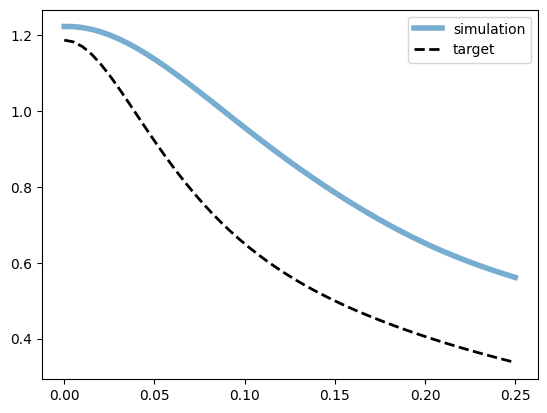

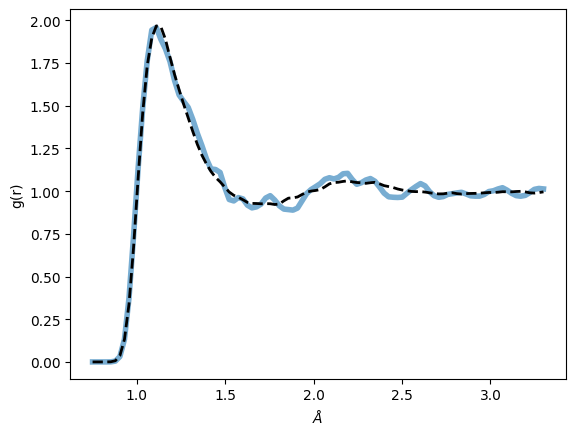

prior:  LJFamily()


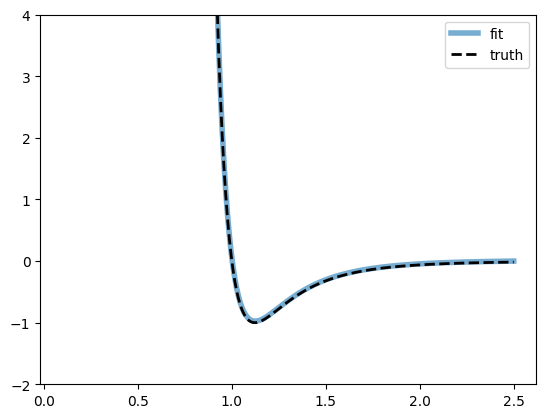

loss.grad_fn: <MulBackward0 object at 0x320d2ed60>
Sigma grad: tensor([-0.0556])
Epsilon grad: tensor([-0.0028])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.0609913244843483 0.0010893717408180237
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322158670>
loss.grad_fn: <MulBackward0 object at 0x32310e8e0>
Sigma grad: tensor([-0.0032])
Epsilon grad: tensor([-0.0033])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04572106525301933 0.002214741660282016
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x320d2ed60>
loss.grad_fn: <MulBackward0 object at 0x322413b80>
Sigma grad: tensor([0.0777])
Epsilon grad: tensor([0.0006])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_

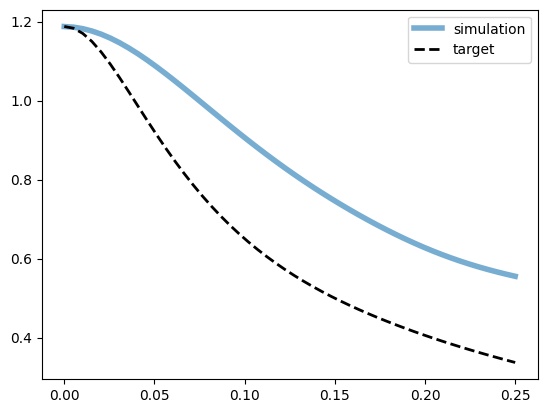

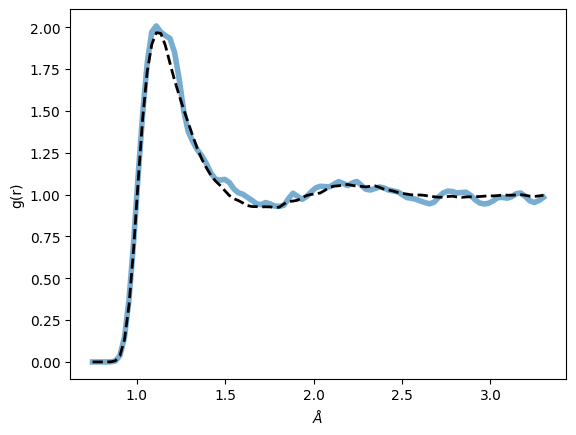

prior:  LJFamily()


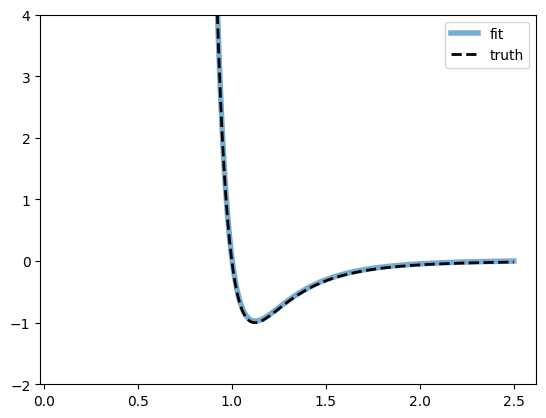

loss.grad_fn: <MulBackward0 object at 0x3227a6ca0>
Sigma grad: tensor([0.0089])
Epsilon grad: tensor([0.0022])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04481171444058418 0.0014145859749987721
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3224eb3a0>
loss.grad_fn: <MulBackward0 object at 0x322825190>
Sigma grad: tensor([0.0948])
Epsilon grad: tensor([0.0079])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.020686982199549675 0.003533664857968688
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x3229f7220>
loss.grad_fn: <MulBackward0 object at 0x3227a6ca0>
Sigma grad: tensor([0.0575])
Epsilon grad: tensor([0.0034])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn

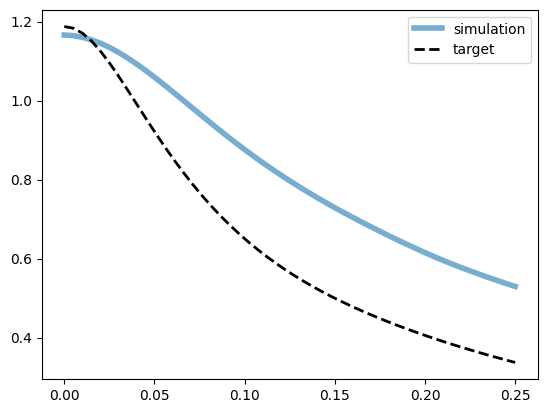

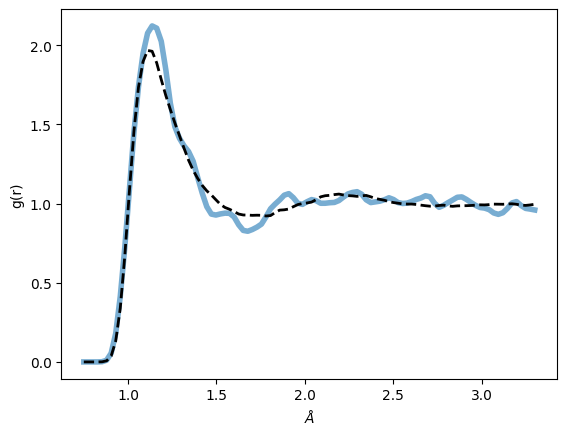

prior:  LJFamily()


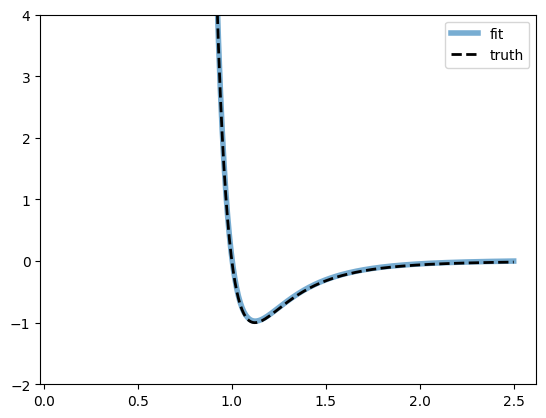

loss.grad_fn: <MulBackward0 object at 0x322158670>
Sigma grad: tensor([0.0230])
Epsilon grad: tensor([0.0066])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03657785430550575 0.0036062293220311403
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322e3b160>
loss.grad_fn: <MulBackward0 object at 0x3223fe5b0>
Sigma grad: tensor([0.0317])
Epsilon grad: tensor([6.4425e-05])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.04885431379079819 0.0021675764583051205
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322899070>
loss.grad_fn: <MulBackward0 object at 0x3229f7220>
Sigma grad: tensor([0.0257])
Epsilon grad: tensor([-0.0016])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon gr

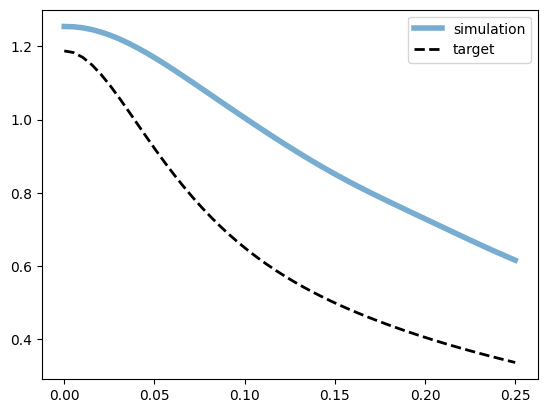

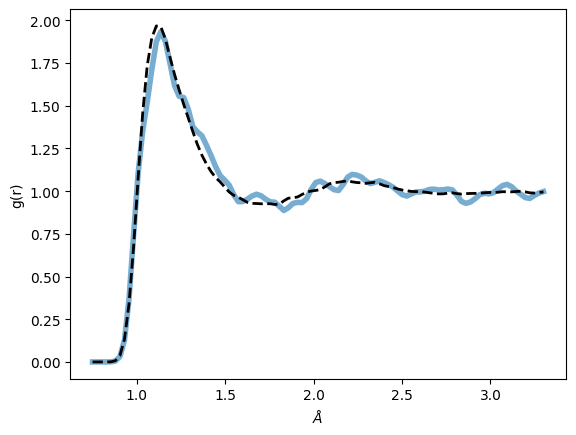

prior:  LJFamily()


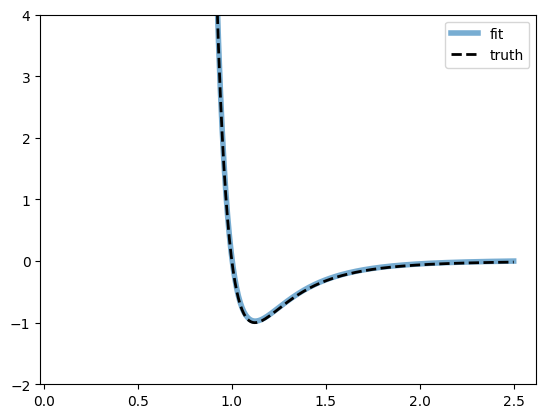

loss.grad_fn: <MulBackward0 object at 0x322aa1fd0>
Sigma grad: tensor([0.0218])
Epsilon grad: tensor([-0.0046])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.09064453095197678 0.0022535391617566347
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322aa1fd0>
loss.grad_fn: <MulBackward0 object at 0x322e3b760>
Sigma grad: tensor([-0.0840])
Epsilon grad: tensor([-0.0089])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad_fn: None
0.03872371092438698 0.004668795969337225
q_t requires_grad: True
v_t requires_grad: True
pv_t requires_grad: True
g_sim requires_grad: True
g_sim grad_fn: <DivBackward0 object at 0x322a58580>
loss.grad_fn: <MulBackward0 object at 0x322e66e80>
Sigma grad: tensor([-0.0844])
Epsilon grad: tensor([0.0007])
Sigma requires grad: True
Epsilon requires grad: True
Sigma grad_fn: None
Epsilon grad

In [39]:
for i in range(n_epochs):

    loss_rdf = torch.Tensor([0.0]).to(device)
    loss_vacf = torch.Tensor([0.0]).to(device)

    # temperature annealing 
    n_train = len(data_str_list)
    for j, sim in enumerate(sim_list[:n_train]): # only simulate config that needs training 

        data_str = (data_str_list + val_str_list)[j]

        # get dt 
        dt = 0.005

        # Simulate 
        v_t, q_t, pv_t = sim.simulate(steps=tau, frequency=tau, dt=dt)
        print("q_t requires_grad:", q_t.requires_grad)
        print("v_t requires_grad:", v_t.requires_grad)
        print("pv_t requires_grad:", pv_t.requires_grad)

        if data_str in val_str_list:
            v_t = v_t.detach()
            q_t = q_t.detach()
            pv_t = pv_t.detach()

        if torch.isnan(q_t.reshape(-1)).sum().item() > 0:
            print("encounter NaN")
            print( 5 - (i / n_epochs) * 5 )
            break

        #_, _, g_sim = rdf_obs_list[j](q_t[::skip])

        # save memory by computing it in serial
        skip = 5
        n_frames = q_t[::skip].shape[0] 
        for idx in range(n_frames):
            if idx == 0:
                _, _, g_sim = rdf_obs_list[j](q_t[::skip][[idx]])
            else:
                g_sim += rdf_obs_list[j](q_t[::skip][[idx]])[2]

        g_sim = g_sim / n_frames
        print("g_sim requires_grad:", g_sim.requires_grad)
        print("g_sim grad_fn:", g_sim.grad_fn)

        # compute vacf 
        vacf_sim = vacf_obs_list[j](v_t)

        if data_str in data_str_list:
            if vacf_target_list[j] is not None:
                loss_vacf += (vacf_sim - vacf_target_list[j][:t_range]).pow(2).mean()
            else:
                loss_vacf += 0.0

            drdf = g_sim - rdf_target_list[j]
            loss_rdf += (drdf).pow(2).mean()#+ JS_rdf(g_sim, rdf_target_list[j])

        obs_log[data_str]['rdf'].append(g_sim.detach().cpu().numpy())
        obs_log[data_str]['vacf'].append(vacf_sim.detach().cpu().numpy())

        if i % 5 ==0 :
            if vacf_target_list[j] is not None:
                vacf_target = vacf_target_list[j][:t_range].detach().cpu().numpy()
            else:
                vacf_target = None
            rdf_target = rdf_target_list[j].detach().cpu().numpy()

            plot_vacf(vacf_sim.detach().cpu().numpy(), vacf_target, 
                fn=data_str + "_{}".format(str(i).zfill(3)), 
                dt=dt,
                path=model_path)

            plot_rdf(g_sim.detach().cpu().numpy(), rdf_target, 
                fn=data_str + "_{}".format(str(i).zfill(3)),
                    path=model_path, 
                    start=rdf_start, 
                    nbins=nbins,
                    end=rdf_obs_list[j].r_axis[-1])

        if i % 5 ==0 :
            print('prior: ', sim.integrator.model.models['pair'].model)
            potential = plot_pair( path=model_path,
                            fn=str(i).zfill(3),
                            #model=sim.integrator.model.models['pairnn'].model, 
                            prior=sim.integrator.model.models['pair'].model, 
                            device=device,
                            target_pot=target_pot.to(device),
                            end=cutoff)

    if train_vacf == "True":
        loss = rdf_weight * loss_rdf +  vacf_weight * loss_vacf
    else:
        loss = rdf_weight * loss_rdf


    print("loss.grad_fn:", loss.grad_fn)

    loss.backward(retain_graph=True)

    print("Sigma grad:", pair.sigma.grad)
    print("Epsilon grad:", pair.epsilon.grad)

    optimizer.step()
    optimizer.zero_grad()
    print("Sigma requires grad:", pair.sigma.requires_grad)
    print("Epsilon requires grad:", pair.epsilon.requires_grad)
    print("Sigma grad_fn:", pair.sigma.grad_fn)
    print("Epsilon grad_fn:", pair.epsilon.grad_fn)

    print(loss_vacf.item(), loss_rdf.item())
    
    scheduler.step(loss)
    
    loss_log.append([loss_vacf.item(), loss_rdf.item() ])

    current_lr = optimizer.param_groups[0]["lr"]

    if current_lr <= 1e-5:
        print("training converged")
        break

    np.savetxt(model_path + '/loss.txt', np.array(loss_log), delimiter=',')

# # save potentials         
# if np.array(loss_log)[-10:, 1].mean() <=  0.005: 
#     np.savetxt(model_path + '/potential.txt',  potential, delimiter=',')


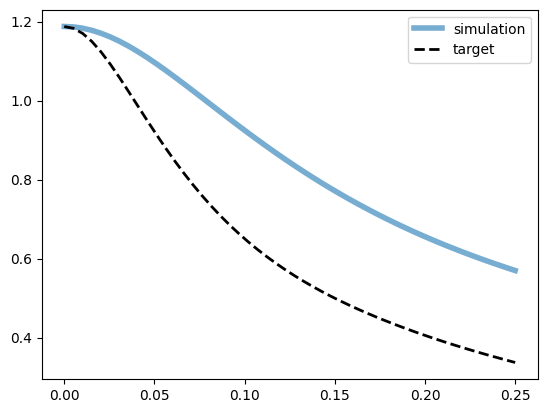

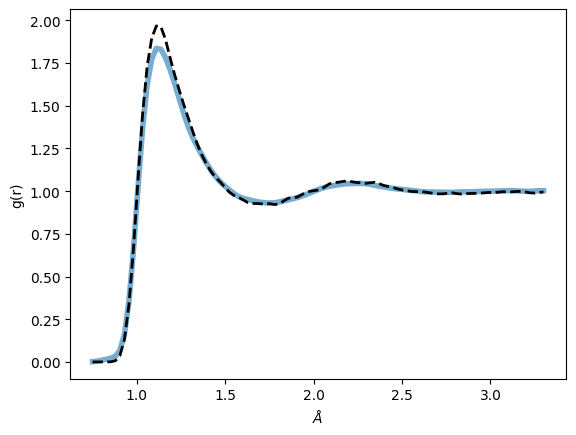

2025-02-23 20:49:10.855 python[75854:19275470] +[IMKClient subclass]: chose IMKClient_Legacy
2025-02-23 20:49:10.856 python[75854:19275470] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


In [40]:

# # save potentials         
# if np.array(loss_log)[-10:, 1].mean() <=  0.005: 
#     np.savetxt(model_path + '/potential.txt',  potential, delimiter=',')

rdf_dev = []

for j, sim in enumerate(sim_list):

    #simulate with no optimization
    data_str = (data_str_list + val_str_list)[j]

    dt = 0.005

    all_vacf_sim = []

    for i in range(n_sim):
        v_t, q_t, pv_t = sim.simulate(steps=tau, frequency=tau, dt=dt)

        # compute VACF 
        vacf_sim = vacf_obs_list[j](v_t).detach().cpu().numpy()
        all_vacf_sim.append(vacf_sim)

    all_vacf_sim = np.array(all_vacf_sim).mean(0)
    
    trajs = torch.Tensor( np.stack( sim.log['positions'])).to(system.device).detach()

    # get targets
    if vacf_target_list[j] is not None:
        vacf_target = vacf_target_list[j][:t_range].detach().cpu().numpy()
    else:
        vacf_target = None
    rdf_target = rdf_target_list[j].detach().cpu().numpy()
    

    # loop over to ocmpute observables 
    all_g_sim = []
    for i in range(len(trajs)):
        _, _, g_sim = rdf_obs_list[j](trajs[[i]])
        all_g_sim.append(g_sim.detach().cpu().numpy())

    all_g_sim = np.array(all_g_sim).mean(0)
    
    # compute target deviation 
    if data_str in data_str_list:
        drdf = np.abs(all_g_sim - rdf_target_list[j].cpu().numpy()).mean()
        rdf_dev.append(drdf) 

    # plot observables 
    plot_vacf(all_vacf_sim, vacf_target, 
        fn=data_str, 
        path=model_path,
        dt=dt,
        save_data=True)

    plot_rdf(all_g_sim, rdf_target, 
        fn=data_str,
            path=model_path, 
            start=rdf_start, 
            nbins=nbins,
            save_data=True,
            end=rdf_obs_list[j].r_axis[-1])


    # rdf_dev = np.abs(all_g_sim - rdf_target).mean()



with save traj

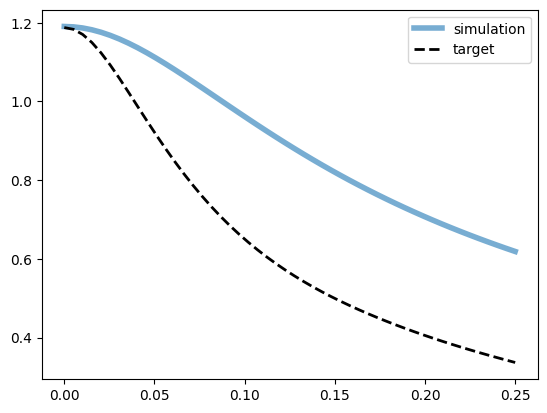

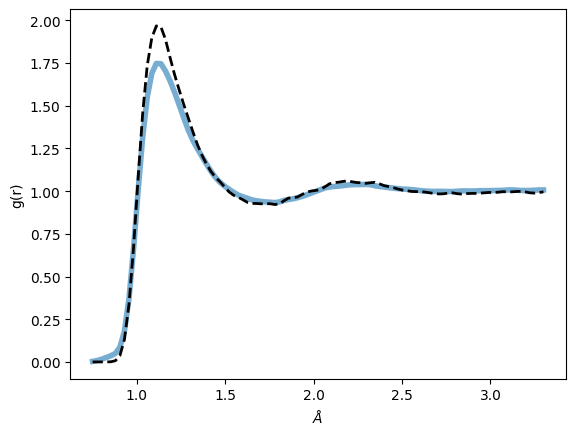

In [32]:
# Save the learned potential if the final RDF loss is below threshold
if np.array(loss_log)[-10:, 1].mean() <= 0.005: 
    potential = plot_pair(path=model_path,
                          fn="final",
                          #model=sim.integrator.model.models['pairnn'].model, 
                          prior=sim.integrator.model.models['pair'].model, 
                          device=device,
                          target_pot=target_pot.to(device),
                          end=cutoff)
    
    np.savetxt(model_path + '/potential.txt', potential, delimiter=',')

rdf_dev = []
import ase
import ase.io

# Function to save trajectory as XYZ file
def save_traj(system, traj, fname, skip=10):
    """
    Saves atomic trajectories as an XYZ file for visualization.

    Parameters:
        system: ASE Atoms object representing the molecular system.
        traj: List of atomic positions at different timesteps.
        fname: Filename for saving the trajectory.
        skip: Interval for saving frames (reduces file size).
    """
    atoms_list = []
    for i, frame in enumerate(traj):
        if i % skip == 0:  # Save every 'skip' frames to reduce file size
            frame = ase.Atoms(positions=frame, numbers=system.get_atomic_numbers())
            atoms_list.append(frame)
    ase.io.write(fname, atoms_list)  # Save as XYZ file

# Final evaluation loop
for j, sim in enumerate(sim_list):

    # Simulate with the trained model (without optimization)
    data_str = (data_str_list + val_str_list)[j]
    train_traj = sim.log['positions']

    # Save training trajectory
    save_traj(system_list[j], train_traj, model_path + '/{}_train.xyz'.format(data_str), skip=10)

    dt = 0.005
    all_vacf_sim = []

    for i in range(n_sim):
        v_t, q_t, pv_t = sim.simulate(steps=tau, frequency=tau, dt=dt)

        # Compute VACF
        vacf_sim = vacf_obs_list[j](v_t).detach().cpu().numpy()
        all_vacf_sim.append(vacf_sim)

    all_vacf_sim = np.array(all_vacf_sim).mean(0)
    
    trajs = torch.Tensor(np.stack(sim.log['positions'])).to(system.device).detach()

    # Get target RDF and VACF
    if vacf_target_list[j] is not None:
        vacf_target = vacf_target_list[j][:t_range].detach().cpu().numpy()
    else:
        vacf_target = None
    rdf_target = rdf_target_list[j].detach().cpu().numpy()
    
    # Compute RDF over all saved trajectories
    all_g_sim = []
    for i in range(len(trajs)):
        _, _, g_sim = rdf_obs_list[j](trajs[[i]])
        all_g_sim.append(g_sim.detach().cpu().numpy())

    all_g_sim = np.array(all_g_sim).mean(0)
    
    # Compute target deviation
    if data_str in data_str_list:
        drdf = np.abs(all_g_sim - rdf_target_list[j].cpu().numpy()).mean()
        rdf_dev.append(drdf) 

    # Plot and save observables (VACF and RDF)
    plot_vacf(all_vacf_sim, vacf_target, 
              fn=data_str, 
              path=model_path,
              dt=dt,
              save_data=True)

    plot_rdf(all_g_sim, rdf_target, 
             fn=data_str,
             path=model_path, 
             start=rdf_start, 
             nbins=nbins,
             save_data=True,
             end=rdf_obs_list[j].r_axis[-1])

    # Save final trajectory (inference trajectory)
    save_traj(system_list[j], np.stack(sim.log['positions']),  
              model_path + '/{}_sim.xyz'.format(data_str), skip=1)


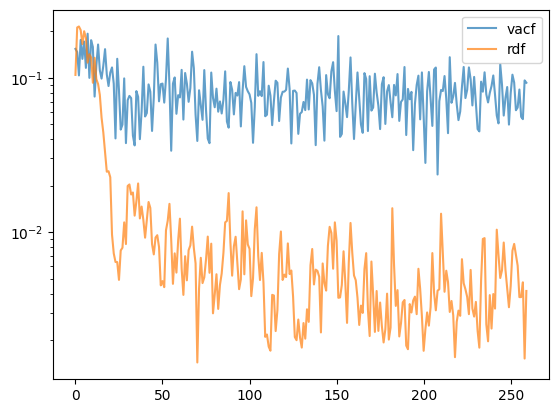

0.005166897550225258


In [33]:
np.savetxt(model_path + '/potential.txt',  potential, delimiter=',')
np.savetxt(model_path + '/rdf_dev.txt', np.array(rdf_dev), delimiter=',')


# save loss curve 
plt.plot(np.array( loss_log)[:, 0], label='vacf', alpha=0.7)
plt.plot(np.array( loss_log)[:, 1], label='rdf', alpha=0.7)
plt.yscale("log")
plt.legend()

plt.savefig(model_path + '/loss.pdf', bbox_inches='tight')
plt.show()
plt.close()

print( np.array(loss_log)[-10:, 1].mean()  )



In [34]:
print(f"Valore finale di Sigma: {pair.sigma.item()}")
print(f"Valore finale di Epsilon: {pair.epsilon.item()}")


Valore finale di Sigma: 1.0095025300979614
Valore finale di Epsilon: 0.7959043979644775
